In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import constants 
from scipy.optimize import curve_fit
from ipywidgets import interact, IntSlider
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

In [2]:
from ion_properties import lead,xenon,calcium

ions=[lead,xenon,calcium]


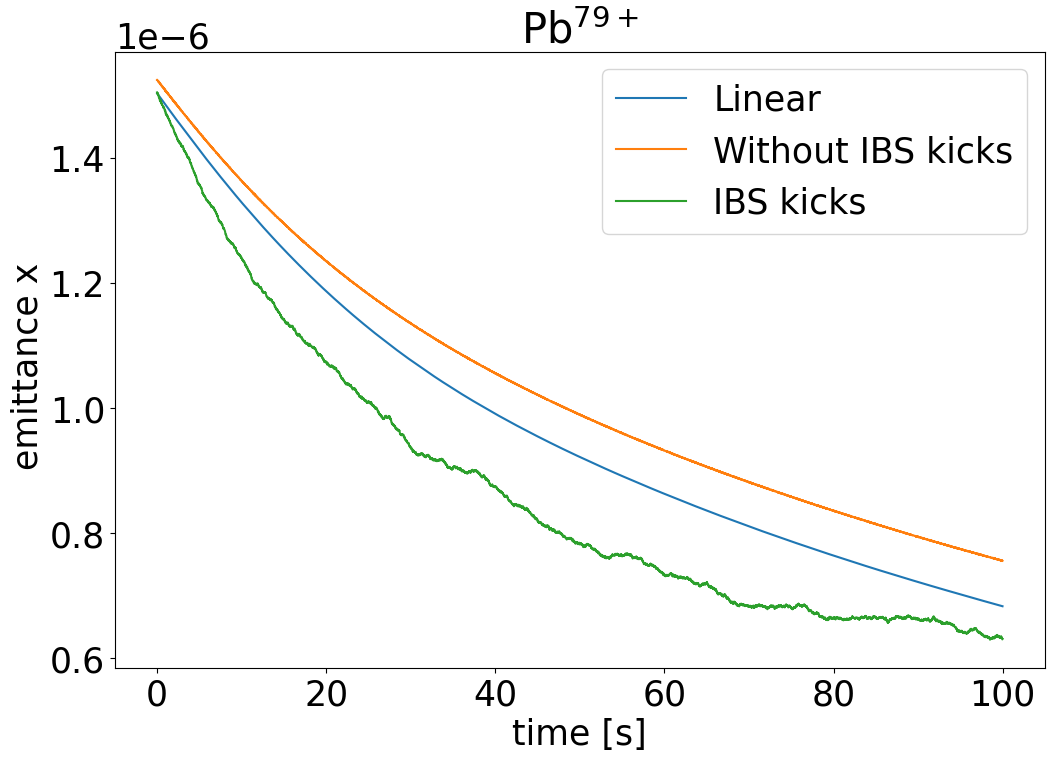

In [3]:
for ion in [lead]:

    loaded_data = np.load(f'../results/transverse/{ion.name}.npz')

    delta_linear = loaded_data['delta']
    zeta_linear = loaded_data['zeta']
    state_linear = loaded_data['state']
    x_linear = loaded_data['x']
    time_linear = loaded_data['time']
    s_per_turn_linear = loaded_data['s_per_turn']
    px_linear = loaded_data['px']
    action_x_linear = loaded_data['action_x']
    action_y_linear = loaded_data['action_y']
    emittance_x_linear = loaded_data['emittance_x']

    loaded_data_ibs = np.load(f'results/IBS/{ion.name}.npz')

    delta_ibs = loaded_data_ibs['delta']
    zeta_ibs = loaded_data_ibs['zeta']
    state_ibs = loaded_data_ibs['state']
    x_ibs = loaded_data_ibs['x']
    time_ibs = loaded_data_ibs['time']
    s_per_turn_ibs = loaded_data_ibs['s_per_turn']
    px_ibs = loaded_data_ibs['px']
    action_x_ibs = loaded_data_ibs['action_x']
    action_y_ibs = loaded_data_ibs['action_y']
    emittance_x_ibs = loaded_data_ibs['emittance_x']

    loaded_data = np.load(f'results/{ion.name}.npz')

    delta = loaded_data['delta']
    zeta = loaded_data['zeta']
    state = loaded_data['state']
    x = loaded_data['x']
    time=loaded_data['time']
    s_per_turn=loaded_data['s_per_turn']
    px=loaded_data['px']
    action_x=loaded_data['action_x']
    action_y=loaded_data['action_y']
    emittance_x=loaded_data['emittance_x']

    

    plt.figure(figsize=(12, 8))
    plt.rcParams.update({'font.size': 25})
    plt.title(f'{ion.name}')
    plt.plot(time_linear,emittance_x_linear,label='Linear')
    plt.plot(time,emittance_x,label='Without IBS kicks')
    plt.plot(time_ibs,emittance_x_ibs,label='IBS kicks')
    plt.xlabel('time [s]')
    plt.ylabel('emittance x ')
    ax = plt.gca()
    ax.yaxis.get_major_formatter().set_useOffset(False)
    # plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
    plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
    plt.legend()
    plt.show()

Transverse cooling for all ions

/tmp/pkruyt/ipykernel_37736/998271452.py:28: OptimizeWarning: Covariance of the parameters could not be estimated
  params, covariance = curve_fit(exponential_func, time, emittance_x)


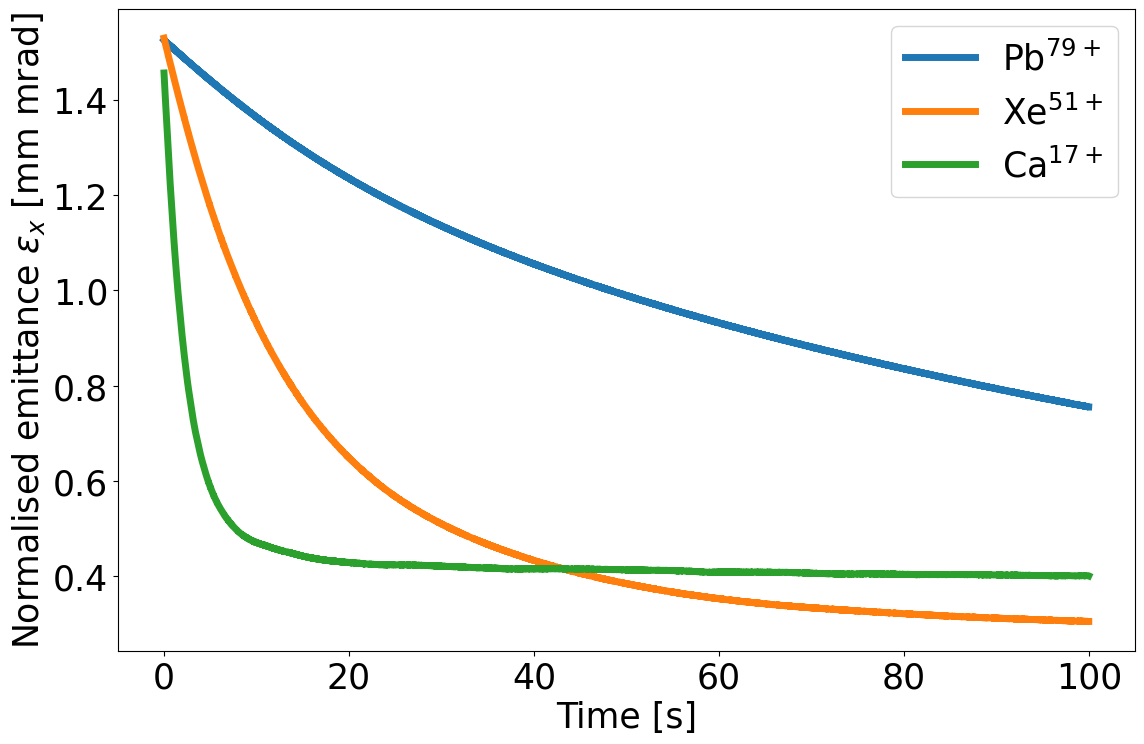

In [4]:
growth_rate_list=[]
ion_names=[ion.name for ion in ions]
ion_energy=[ion.hw0 for ion in ions]


plt.figure(figsize=(12, 8))
plt.rcParams.update({'font.size': 25})

for ion in ions:
    loaded_data = np.load(f'results/{ion.name}.npz')

    delta = loaded_data['delta']
    zeta = loaded_data['zeta']
    state = loaded_data['state']
    x = loaded_data['x']*1e3
    time=loaded_data['time']
    s_per_turn=loaded_data['s_per_turn']
    px=loaded_data['px']
    action_x=loaded_data['action_x']
    action_y=loaded_data['action_y']
    emittance_x=loaded_data['emittance_x']

     # Define the exponential function
    def exponential_func(x, a, b):
        return emittance_x[0] * np.exp(x * b)

    # Fit the data to the exponential function
    params, covariance = curve_fit(exponential_func, time, emittance_x)

    # Extract the parameters
    a, b = params
    growth_rate_list.append(b)

    plt.plot(time,emittance_x*1e6, label=f'{ion.name}', linewidth=5.0)
plt.xlabel(r'Time [s]')
plt.ylabel(r'Normalised emittance $\epsilon_x$ [mm mrad]')
plt.legend()
plt.tight_layout()
plt.savefig('Transverse_laser_cooling_rates.png', dpi=300)
plt.show()

In [5]:
data=np.load(f'results/IBS_custom/{ion.name}_new_kicks.npz')
delta = data['delta']
zeta=data['zeta']
state=data['state']
emittance_x = data['emittance_x']
time = data['time']
rms_dp_p = np.std(delta, axis=1)
emittance_x = emittance_x[:]
rms_dp_p = rms_dp_p[:]
num_particles=np.sum(state,axis=1)
index_closest_to_40 = np.argmin(np.abs(time_linear - 40))




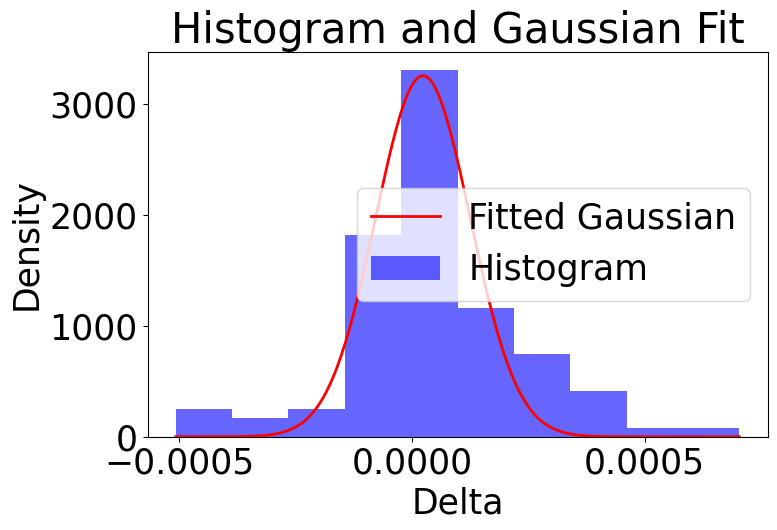

In [6]:
import numpy as np
import scipy.optimize as opt
def gaussian(x, A, mu, sigma):
        return A * np.exp(-((x - mu) ** 2) / (2 * sigma ** 2))


data=delta[69]
bins = int(np.sqrt(len(data)))    
hist, bin_edges = np.histogram(data, bins=bins, density=True)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2  

A_init = max(hist)  
mu_init = np.mean(data)  
sigma_init = np.std(data)  

p0 = [A_init, mu_init, sigma_init]

params, covariance = opt.curve_fit(gaussian, bin_centers, hist, p0=p0)
A_fit, mu_fit, sigma_fit = params

# Plot histogram
plt.figure(figsize=(8, 5))
plt.bar(bin_centers, hist, width=(bin_edges[1] - bin_edges[0]), alpha=0.6, label="Histogram", color='blue')

# Plot fitted Gaussian
x_fit = np.linspace(min(data), max(data), 300)
y_fit = gaussian(x_fit, A_fit, mu_fit, sigma_fit)
plt.plot(x_fit, y_fit, label="Fitted Gaussian", color='red', linewidth=2)

# Labels and legend
plt.xlabel("Delta")
plt.ylabel("Density")
plt.legend()
plt.title("Histogram and Gaussian Fit")
plt.show()

In [7]:
ion=calcium
data=np.load(f'results/IBS_custom/{ion.name}_new_kicks.npz')
delta = data['delta']
zeta=data['zeta']
state=data['state']
emittance_x = data['emittance_x']
time = data['time']
rms_dp_p = np.std(delta, axis=1)
emittance_x = emittance_x[:]
rms_dp_p = rms_dp_p[:]
num_particles=np.sum(state,axis=1)
index_closest_to_40 = np.argmin(np.abs(time - 40))


#load IBS results small emittance
#IBS_small_results = np.load(f'results/IBS/{ion_loop.name}_small.npz')

# delta_IBS_small = IBS_small_results['delta']
# emittance_x_IBS_small = IBS_small_results['emittance_x']
# time_IBS_small = IBS_small_results['time']
# rms_dp_p_IBS_small = np.std(delta_IBS_small, axis=1)      

all_data = np.concatenate(delta)
x_min, x_max = all_data.min(), all_data.max()
x = np.linspace(x_min, x_max, 100)

bins = 50

# Determine the maximum y value across all histograms
hist_counts = [np.histogram(data, bins=bins)[0] for data in delta]
y_max = max(max(counts) for counts in hist_counts)

# Function to calculate RMS of the core
def core_rms(delta, percentile=100):
    lower_bound = np.percentile(delta, (100 - percentile) / 2)
    upper_bound = np.percentile(delta, 100 - (100 - percentile) / 2)
    core_values = delta[(delta >= lower_bound) & (delta <= upper_bound)]
    return np.std(core_values)

rms_dp_p_IBS_core = np.array([core_rms(delta) for delta in delta])
rms_dp_p_linear_core = np.array([core_rms(delta) for delta in delta_linear])

mask = (state == 1) | (state == 2)

# Function to plot histograms at a given turn and overlay RMS as width
def plot_histogram(turn):
    plt.figure(figsize=(12, 8))
    plt.rcParams.update({'font.size': 20})

    # Kill particles where delta > threshold
    mask_turn=mask[turn]
    data=delta[turn][mask_turn]
    p10, p90 = np.percentile(data, [20, 80])

    # Select only values within the central 80% range
    filtered_data = data[(data >= p10) & (data <= p90)]

    # Fit a Gaussian to the filtered data
    mu, sigma = norm.fit(filtered_data)
    mask_kill = np.abs(data) > 10*sigma
    
    plt.title(f'With IBS: Time {time[turn]:.1f}')
    plt.suptitle(f"Particles left:{num_particles[turn]}", fontsize=16)
    # Plot histograms
    plt.hist(delta[turn], bins=bins, histtype='step', label='With IBS')
    p = norm.pdf(x, mu, sigma)
    plt.plot(x, p/1000, 'r-', linewidth=2, label=f"Gaussian Fit\nμ={mu:.2e}, σ={sigma:.2e}")
    # Plot RMS as vertical lines
    plt.axvline(x=np.std(delta[turn]), color='orange', linestyle='--', label='RMS Without IBS')
    plt.axvline(x=-np.std(delta[turn]), color='orange', linestyle='--')

    plt.axvline(x=sigma, color='red', linestyle='--', label='mu')
    plt.axvline(x=-sigma, color='red', linestyle='--')

    plt.axvline(x=10*sigma, color='black', linestyle='--', label='discard')
    plt.axvline(x=-10*sigma, color='black', linestyle='--')
    
    plt.xlim(x_min, x_max)  # Set the x-axis limits
    plt.ylim(0, y_max)  # Set the y-axis limits
    plt.ylabel('Count')
    plt.xlabel('dp/p ')
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()



interact(plot_histogram, turn=IntSlider(min=0, max=len(time)-1, step=1, value=0))



interactive(children=(IntSlider(value=0, description='turn', max=199), Output()), _dom_classes=('widget-intera…

<function __main__.plot_histogram(turn)>

davide plot

In [8]:
# data_to_use = delta[60]
# # p10, p90 = np.percentile(data, [10, 90])

# cipp=[]
# #for data_to_use in [delta[71]]:
# for data_to_use in x:

#     # compute histogram
#     hist, bin_edges = np.histogram(data_to_use, density=True, bins=20)
#     bin_centers = (bin_edges[1:]+bin_edges[0:-1])/2

#     # fita to Gaussian
#     def gauss_function(x, a, x0, sigma):
#         return a*np.exp(-(x-x0)**2/(2*sigma**2))
#     try:
#         popt, pcov = curve_fit(gauss_function, bin_centers, hist, p0 = [1, 0, np.std(data_to_use)])
#     except:
#         cipp.append(np.nan)
#         continue
#     popt[2] = np.abs(popt[2])
#     relative_error = (np.std(data_to_use)-popt[2])/popt[2]
    
#     if relative_error > 0.3:
#         keep_only_idx = (np.abs(data_to_use) < 3*popt[2])
#         # compute histogram
#         hist, bin_edges = np.histogram(data_to_use[keep_only_idx], density=True, bins=20)
#         bin_centers = (bin_edges[1:]+bin_edges[0:-1])/2

#         # fita to Gaussian
#         def gauss_function(x, a, x0, sigma):
#             return a*np.exp(-(x-x0)**2/(2*sigma**2))
#         try:
#             popt, pcov = curve_fit(gauss_function, bin_centers, hist, p0 = [1, 0, np.std(data_to_use[keep_only_idx])])
#         except:
#             cipp.append(np.nan)
#             continue
#         popt[2] = np.abs(popt[2])
#         relative_error = (np.std(data_to_use[keep_only_idx])-popt[2])/popt[2]

#     cipp.append(relative_error)
#     #print(f"{relative_error:.2f}")

# plt.figure(figsize=(10,8))
# plt.stem(bin_centers,hist)
# plt.plot(x, gauss_function(x, *popt), label='fit')

# plt.axvline(x=np.std(data_to_use[keep_only_idx]), color='orange', linestyle='--', label='RMS Without IBS')
# plt.axvline(x=-np.std(data_to_use[keep_only_idx]), color='orange', linestyle='--')
# plt.axvline(x=popt[2], color='red', linestyle='--', label='gaussian sigma')
# plt.axvline(x=-popt[2], color='red', linestyle='--')
# plt.legend()


# plt.figure(figsize=(10,8))
# plt.plot(cip)
# plt.plot(cipp, 'r--')
# plt.show()


In [9]:
data = np.load(f'results/IBS_custom/{calcium.name}_new_kicks.npz')

delta = data['delta']


def freedman_diaconis_bins(data):
    q25, q75 = np.percentile(data, [25, 75])
    iqr = q75 - q25
    bin_width = 2 * iqr * len(data) ** (-1 / 3)
    bins = int((np.max(data) - np.min(data)) / bin_width)
    return max(1, bins)  # Ensure at least 1 bin

def estimate_sigma_from_pdf_peak(data):
    """
    Estimate Gaussian sigma per turn from the peak of the PDF,
    assuming an approximately Gaussian distribution.
    """
    sigma_list = []
    delta = data['delta']
    state = data['state']

    for turn in range(delta.shape[0]):
        data_turn = delta[turn][state[turn] > 0]

        if len(data_turn) < 2:
            sigma_list.append(np.nan)
            continue

        n_bins = freedman_diaconis_bins(data_turn)

        data_min = np.min(data_turn)
        data_max = np.max(data_turn)
        bin_edges = np.linspace(data_min, data_max, n_bins + 1)

        bin_width = bin_edges[1] - bin_edges[0]
        indices = np.floor((data_turn - bin_edges[0]) / bin_width).astype(int)
        indices = np.clip(indices, 0, n_bins - 1)

        counts = np.zeros(n_bins, dtype=float)
        for i in range(len(data_turn)):
            counts[indices[i]] += 1

        counts /= (np.sum(counts) * bin_width)

        max_pdf = np.max(counts)
        sigma_est = 1.0 / (np.sqrt(2.0 * np.pi) * max_pdf) if max_pdf > 0 else np.nan

        sigma_list.append(sigma_est)

    return np.array(sigma_list)


def gauss_sigma(data):

    sigma_list=[]
    delta=data['delta']
    state=data['state']
    for turn in range(delta.shape[0]):
        data=delta[turn][state[turn] > 0]
        bins = int(np.sqrt(len(data)))  
        #bins=10  
        hist, bin_edges = np.histogram(data, bins=bins, density=True)
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2  

        A_init = max(hist)  
        mu_init = np.mean(data)  
        sigma_init = np.std(data)  

        p0 = [A_init, mu_init, sigma_init]

        params, covariance = opt.curve_fit(gaussian, bin_centers, hist, p0=p0)
        A_fit, mu_fit, sigma_fit = params

        sigma_list.append(sigma_fit)

    return sigma_list

def core_width(data):
    core_width_list=[]
    delta=data['delta']
    state=data['state']
    for turn in range(delta.shape[0]):
        data=delta[turn]
        p20, p80 = np.percentile(data, [15, 85])
        core = data[(data >= p20) & (data <= p80)]
        core_width=(p80-p20)/2
        core_width_list.append(core_width)
    return core_width_list

def plot_quiver(emittance, rms_dp_p, time, color, label):
    num_segments = 10
    step_size = len(time) // num_segments

    for j in range(num_segments):
        start_idx = j * step_size
        end_idx = min((j + 1) * step_size, len(time) - 1)
        
        start_x = emittance[start_idx]
        end_x = emittance[end_idx]
        
        start_y = rms_dp_p[start_idx]
        end_y = rms_dp_p[end_idx]

        label_str = label if j == 0 else None  
        
        arrow = plt.quiver(start_x, start_y, end_x - start_x, end_y - start_y, scale=1,
                            scale_units='xy', angles='xy', color=color, width=0.003,label=label_str)
        
        time_annotation_x = end_x
        time_annotation_y = end_y
        if j == num_segments - 1:
            time_annotation_text = f"{time[end_idx]:.1f}s"
            time_annotation_y = 0.98 * time_annotation_y
        else:
            time_annotation_text = f"{time[end_idx]:.1f}s"
        #plt.text(time_annotation_x, time_annotation_y, time_annotation_text, color='black', fontsize=10, ha='right', va='bottom')

0it [00:00, ?it/s]

/tmp/pkruyt/ipykernel_37736/1589120292.py:71: OptimizeWarning: Covariance of the parameters could not be estimated
  params, covariance = opt.curve_fit(gaussian, bin_centers, hist, p0=p0)
1it [00:21, 21.33s/it]


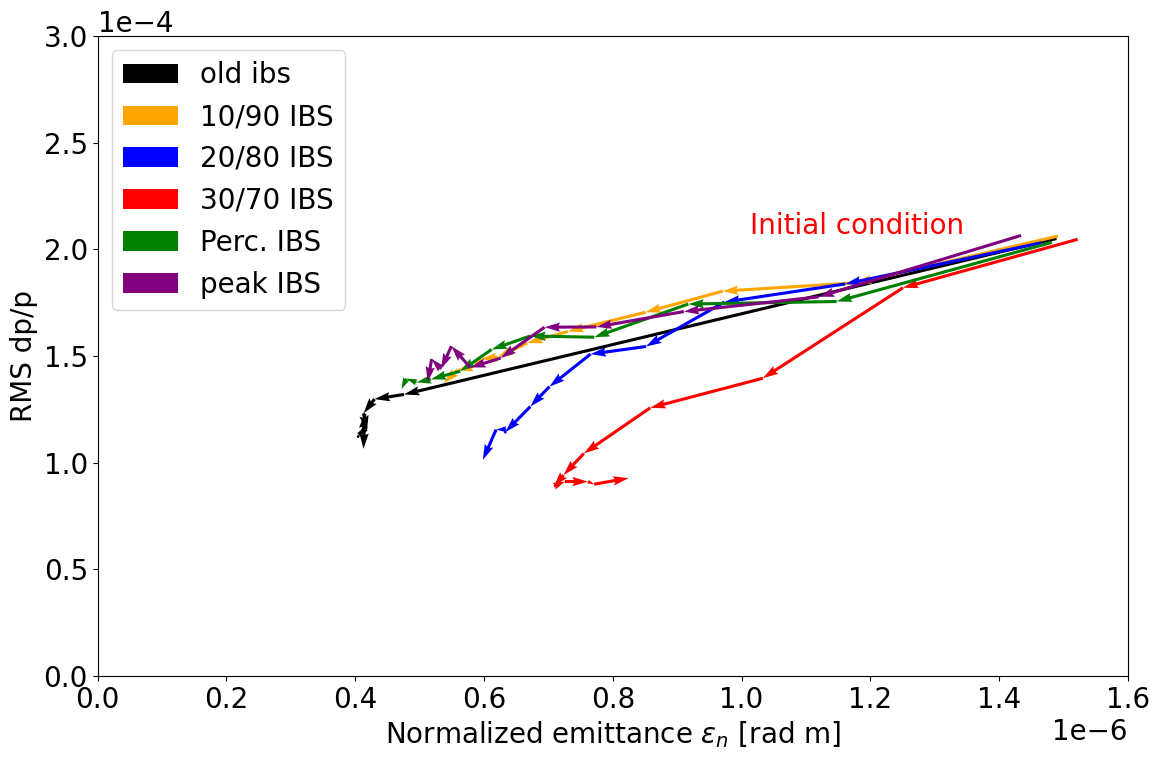

In [10]:
from tqdm import tqdm
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

plt.figure(figsize=(12, 8))
plt.rcParams.update({'font.size': 20})

cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']

for i, ion_loop in tqdm(enumerate([calcium])):    
    
    data_custom = np.load(f'results/IBS_custom/{ion_loop.name}_new_kicks.npz')

    delta_custom = data_custom['delta']
    emittance_x_custom = data_custom['emittance_x']
    time_custom = data_custom['time']
    rms_dp_p_custom = np.std(delta_custom, axis=1)
    sigma_list_custom=gauss_sigma(data_custom)
    

    data_old_ibs = np.load(f'results/IBS/{ion_loop.name}.npz')

    delta_old_ibs = data_old_ibs['delta']
    emittance_x_old_ibs = data_old_ibs['emittance_x']
    time_old_ibs = data_old_ibs['time']
    rms_dp_p_old_ibs = np.std(delta_old_ibs, axis=1)
    sigma_list_old_ibs=gauss_sigma(data_old_ibs)  
    core_width_old_ibs=core_width(data_old_ibs)

    max_pdf_old_ibs = estimate_sigma_from_pdf_peak(data_old_ibs)

    data_full_ibs = np.load(f'results/IBS_custom/{ion_loop.name}_ibs_full.npz')

    delta_full_ibs = data_full_ibs['delta']
    emittance_x_full_ibs = data_full_ibs['emittance_x']
    time_full_ibs = data_full_ibs['time']
    rms_dp_p_full_ibs = np.std(delta_full_ibs, axis=1)
    sigma_list_full_ibs=gauss_sigma(data_full_ibs)    

    data_no_ibs = np.load(f'results/IBS_custom/{ion_loop.name}_no_ibs.npz')

    delta_no_ibs = data_no_ibs['delta']
    emittance_x_no_ibs = data_no_ibs['emittance_x']
    time_no_ibs = data_no_ibs['time']
    rms_dp_p_no_ibs = np.std(delta_no_ibs, axis=1)
    sigma_list_no_ibs=gauss_sigma(data_no_ibs)

    # data_10_90 = np.load(f'results/IBS_custom/{ion_loop.name}_10_90.npz')

    # delta_10_90 = data_10_90['delta']
    # emittance_x_10_90 = data_10_90['emittance_x']
    # time_10_90 = data_10_90['time']
    # rms_dp_p_10_90 = np.std(delta_10_90, axis=1)
    # sigma_list_10_90=gauss_sigma(data_10_90)    

    data_10_90 = np.load(f'results/IBS_custom/{ion_loop.name}_10_90.npz')

    delta_10_90 = data_10_90['delta']
    emittance_x_10_90 = data_10_90['emittance_x']
    time_10_90 = data_10_90['time']
    rms_dp_p_10_90 = np.std(delta_10_90, axis=1)
    sigma_list_10_90=gauss_sigma(data_10_90)
    core_width_10_90=core_width(data_10_90)

    data_20_80 = np.load(f'results/IBS_custom/{ion_loop.name}_20_80.npz')

    delta_20_80 = data_20_80['delta']
    emittance_x_20_80 = data_20_80['emittance_x']
    time_20_80 = data_20_80['time']
    rms_dp_p_20_80 = np.std(delta_20_80, axis=1)
    sigma_list_20_80=gauss_sigma(data_20_80)
    core_width_20_80=core_width(data_20_80)

    data_30_70 = np.load(f'results/IBS_custom/{ion_loop.name}_30_70.npz')

    delta_30_70 = data_30_70['delta']
    emittance_x_30_70 = data_30_70['emittance_x']
    time_30_70 = data_30_70['time']
    rms_dp_p_30_70 = np.std(delta_30_70, axis=1)
    sigma_list_30_70=gauss_sigma(data_30_70)
    core_width_30_70=core_width(data_30_70)

    data_perc = np.load(f'results/IBS_custom/{ion_loop.name}_percentile_sigma.npz')

    delta_perc = data_perc['delta']
    emittance_x_perc = data_perc['emittance_x']
    time_perc = data_perc['time']
    rms_dp_p_perc = np.std(delta_perc, axis=1)
    sigma_list_perc=gauss_sigma(data_perc)
    core_width_perc=core_width(data_perc)
    max_pdf_perc = estimate_sigma_from_pdf_peak(data_perc)

    data_peak = np.load(f'results/IBS_custom/{ion_loop.name}_peak_davide.npz')
    delta_peak = data_peak['delta']
    zeta_peak = data_peak['zeta']
    emittance_x_peak = data_peak['emittance_x']
    time_peak = data_peak['time']
    rms_dp_p_peak = np.std(delta_peak, axis=1)
    sigma_list_peak=gauss_sigma(data_peak)
    core_width_peak=core_width(data_peak)
    max_pdf_peak = estimate_sigma_from_pdf_peak(data_peak)

    data_peter = np.load(f'results/IBS_custom/{ion_loop.name}_core_peter.npz')
    delta_peter = data_peter['delta']
    zeta_peter = data_peter['zeta']
    emittance_x_peter = data_peter['emittance_x']
    time_peter = data_peter['time']
    rms_dp_p_peter = np.std(delta_peter, axis=1)
    sigma_list_peter=gauss_sigma(data_peter)
    core_width_peter=core_width(data_peter)
    max_pdf_peter = estimate_sigma_from_pdf_peak(data_peter)


    emittance_x_values = emittance_x_custom[:]
    rms_dp_p_values = rms_dp_p_custom[:]   
    
# plot_quiver(emittance_x_custom, sigma_list_custom, time_custom, 'orange', label='sigma only long. ibs')
# plot_quiver(emittance_x_old_ibs, sigma_list_old_ibs, time_old_ibs, 'blue', label='sigma old ibs')
# plot_quiver(emittance_x_full_ibs, sigma_list_full_ibs, time_full_ibs, 'red', label='sigma full ibs')     
  
# plot_quiver(emittance_x_custom, rms_dp_p_custom, time_custom, 'black', label='only long. gaussian ibs')
plot_quiver(emittance_x_old_ibs, rms_dp_p_old_ibs, time_old_ibs, 'black', label='old ibs')
# plot_quiver(emittance_x_full_ibs, rms_dp_p_full_ibs, time_full_ibs, 'blue', label='full gaussian ibs') 


# plot_quiver(emittance_x_no_ibs, rms_dp_p_no_ibs, time_10_90, 'yellow', label='no IBS') 

plot_quiver(emittance_x_10_90, rms_dp_p_10_90, time_10_90, 'orange', label='10/90 IBS') 
plot_quiver(emittance_x_20_80, rms_dp_p_20_80, time_20_80, 'blue', label='20/80 IBS') 
plot_quiver(emittance_x_30_70, rms_dp_p_30_70, time_30_70, 'red', label='30/70 IBS') 

plot_quiver(emittance_x_perc, rms_dp_p_perc, time_perc, 'green', label='Perc. IBS') 


plot_quiver(emittance_x_peak, rms_dp_p_peak, time_10_90, 'purple', label='peak IBS') 

injection_nemitt = emittance_x[0]
injection_dp_p = rms_dp_p[0]

#plt.scatter(injection_nemitt, injection_dp_p, color='red', label='Initial condition')
plt.text(0.97*injection_nemitt, 0.98*injection_dp_p, 'Initial condition', color='red', fontsize=20, ha='right')        

plt.xlim([0, 1.6*1e-6])
plt.ylim([0, 3*1e-4])
plt.xlabel('Normalized emittance $\\epsilon_n$ [rad m]', fontsize=20)
plt.ylabel('RMS dp/p', fontsize=20)
plt.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))

# plt.legend(handles=[
#     Line2D([0], [0], linestyle='-', color='black',  label='rms dp_p'),
#     Line2D([0], [0], linestyle='--', color='orange', label='gaus sigma'),
          
# ], loc='lower right')

plt.legend(loc='upper left')

plt.tight_layout()
#plt.savefig('figures/Equilibrium_emittance.png', dpi=300)
plt.show()

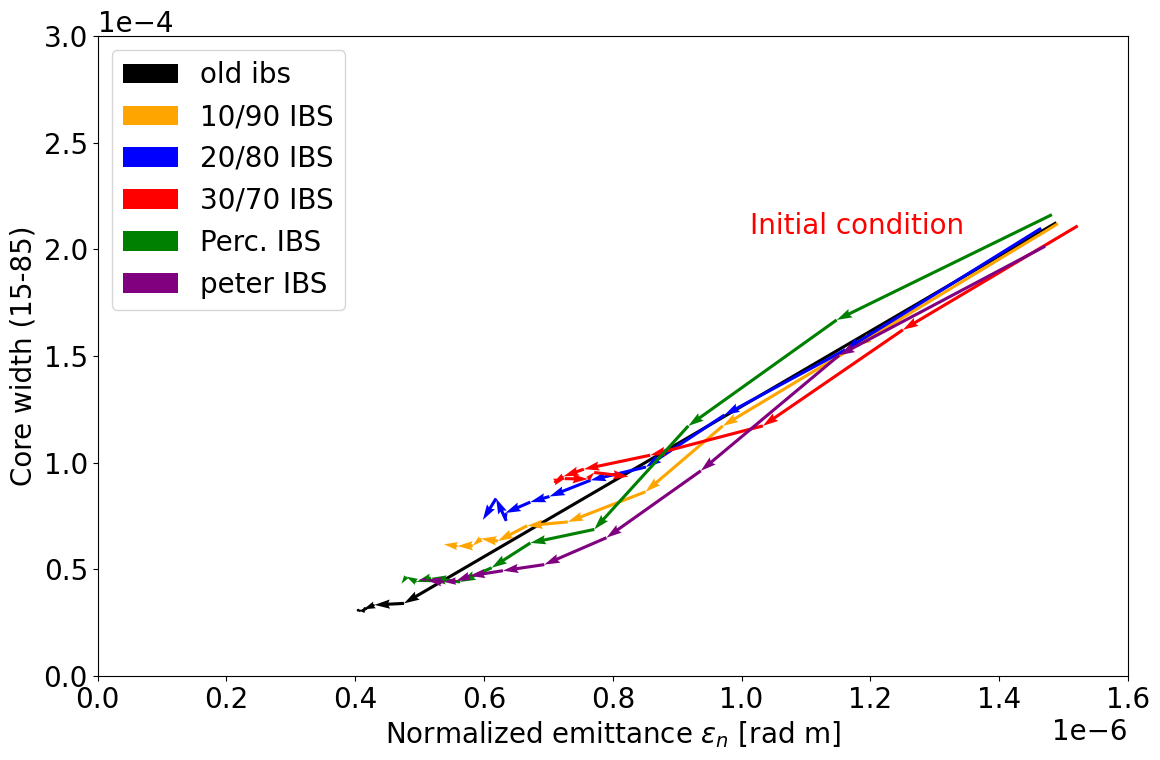

In [11]:
plt.figure(figsize=(12, 8))
plot_quiver(emittance_x_old_ibs, core_width_old_ibs, time_old_ibs, 'black', label='old ibs')
# plot_quiver(emittance_x_full_ibs, rms_dp_p_full_ibs, time_full_ibs, 'blue', label='full gaussian ibs') 
plot_quiver(emittance_x_10_90, core_width_10_90, time_10_90, 'orange', label='10/90 IBS') 
plot_quiver(emittance_x_20_80, core_width_20_80, time_20_80, 'blue', label='20/80 IBS') 
plot_quiver(emittance_x_30_70, core_width_30_70, time_30_70, 'red', label='30/70 IBS') 

plot_quiver(emittance_x_perc, core_width_perc, time_perc, 'green', label='Perc. IBS') 

plot_quiver(emittance_x_peter, core_width_peter, time_peter, 'purple', label='peter IBS') 


injection_nemitt = emittance_x[0]
injection_dp_p = rms_dp_p[0]

#plt.scatter(injection_nemitt, injection_dp_p, color='red', label='Initial condition')
plt.text(0.97*injection_nemitt, 0.98*injection_dp_p, 'Initial condition', color='red', fontsize=20, ha='right')        

plt.xlim([0, 1.6*1e-6])
plt.ylim([0, 3*1e-4])
plt.xlabel('Normalized emittance $\\epsilon_n$ [rad m]', fontsize=20)
plt.ylabel('Core width (15-85)', fontsize=20)
plt.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))

# plt.legend(handles=[
#     Line2D([0], [0], linestyle='-', color='black',  label='rms dp_p'),
#     Line2D([0], [0], linestyle='--', color='orange', label='gaus sigma'),
          
# ], loc='lower right')

plt.legend(loc='upper left')

plt.tight_layout()
#plt.savefig('figures/Equilibrium_emittance.png', dpi=300)
plt.show()

In [12]:
idx_to_look_at  = -1

print(f"{time_full_ibs[idx_to_look_at]} -> {np.std(delta_full_ibs[idx_to_look_at])}")
print(f"{time_old_ibs[idx_to_look_at]} -> {np.std(delta_old_ibs[idx_to_look_at])}")
print(f"{time_custom[idx_to_look_at]} -> {np.std(delta_custom[idx_to_look_at])}")
print(f"{time_20_80[idx_to_look_at]} -> {np.std(delta_20_80[idx_to_look_at])}")

print('------------------------------------------------------------------------------------------------------')

print(f"{time_10_90[idx_to_look_at]} -> {np.std(delta_10_90[idx_to_look_at])}")
print(f"{time_20_80[idx_to_look_at]} -> {np.std(delta_20_80[idx_to_look_at])}")
print(f"{time_30_70[idx_to_look_at]} -> {np.std(delta_30_70[idx_to_look_at])}")

1.9865430620330866 -> 0.00015511030187011614
99.98600657951455 -> 0.00012470208702294516
1.9865430620330866 -> 0.0001611103105417588
19.98522216176 -> 0.00010128810869576888
------------------------------------------------------------------------------------------------------
19.98522216176 -> 0.00014470699666792344
19.98522216176 -> 0.00010128810869576888
19.98522216176 -> 9.30063658068861e-05


In [13]:
time_old_ibs[1000]

np.float64(9.982628452427571)

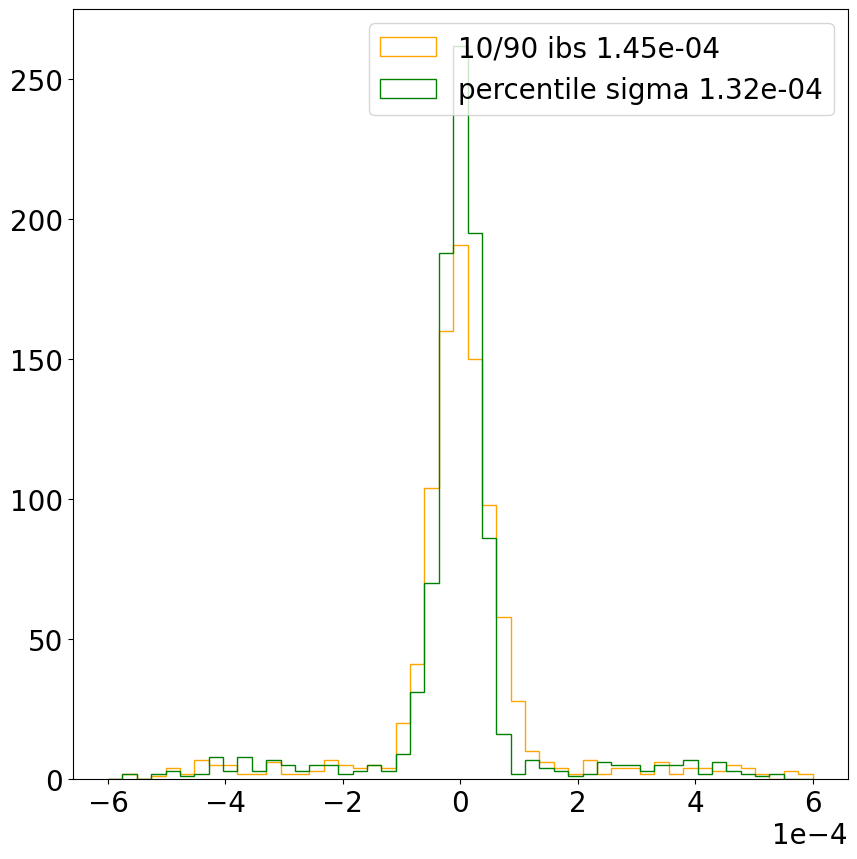

In [14]:
idx_to_look_at = -1
bins=np.linspace(-6e-4,6e-4,50)
plt.figure(figsize=(10,10))
# plt.hist(delta_full_ibs[idx_to_look_at], 100,histtype='step',density=True,label='sigma full ibs')
# plt.hist(delta_old_ibs[idx_to_look_at], 100,histtype='step',density=True,label='sigma old ibs')
# plt.hist(delta_custom[idx_to_look_at],100,histtype='step',density=True,label='sigma only long. ibs')

#plt.hist(delta_no_ibs[idx_to_look_at],bins,histtype='step',color='yellow',density=False,label=f'no ibs {np.std(delta_no_ibs[idx_to_look_at]):.2e}')
#plt.hist(delta_old_ibs[idx_to_look_at],bins,histtype='step',color='black',density=False,label=f'old ibs {np.std(delta_old_ibs[idx_to_look_at]):.2e}')
plt.hist(delta_10_90[idx_to_look_at],bins,histtype='step',color='orange',density=False,label=f'10/90 ibs {np.std(delta_10_90[idx_to_look_at]):.2e}')
#plt.hist(delta_20_80[idx_to_look_at],bins,histtype='step',color='blue',density=False,label=f'20/80 ibs {np.std(delta_20_80[idx_to_look_at]):.2e}')
#plt.hist(delta_30_70[idx_to_look_at],bins,histtype='step',color='red',density=False,label=f'30/70 ibs {np.std(delta_30_70[idx_to_look_at]):.2e}')

plt.hist(delta_perc[idx_to_look_at],bins,histtype='step',color='green',density=False,label=f'percentile sigma {np.std(delta_perc[idx_to_look_at]):.2e}')


# plt.axvline(-np.std(delta_perc[idx_to_look_at]))
# plt.axvline(np.std(delta_perc[idx_to_look_at]))
#plt.xlim([-0.00025,0.00025])
plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
plt.legend()
plt.show()


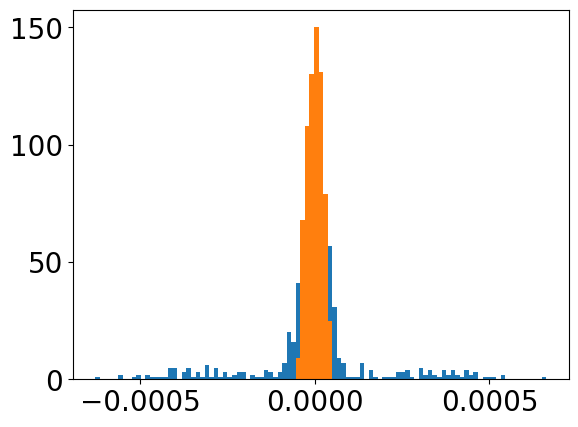

In [15]:
delta_perc_final=delta_perc[-1]

p20, p80 = np.percentile(delta_perc_final, [15, 85])
core = delta_perc_final[(delta_perc_final >= p20) & (delta_perc_final <= p80)]



bins = np.linspace(min(delta_perc_final), max(delta_perc_final), 100)
plt.figure()

plt.hist(delta_perc_final,bins=bins)
plt.hist(core,bins=bins)
plt.show()

In [16]:
def freedman_diaconis_bins(data):
    q25, q75 = np.percentile(data, [25, 75])
    iqr = q75 - q25
    bin_width = 2 * iqr * len(data) ** (-1 / 3)
    bins = int((np.max(data) - np.min(data)) / bin_width)
    return max(1, bins)  # Ensure at least 1 bin

bnn=freedman_diaconis_bins(delta_perc_final)

print(bnn)

129


In [17]:
min(delta_perc_final)

np.float64(-0.0006286695023492994)

f_max = 11149.621964584292
sigma = 3.5781e-05


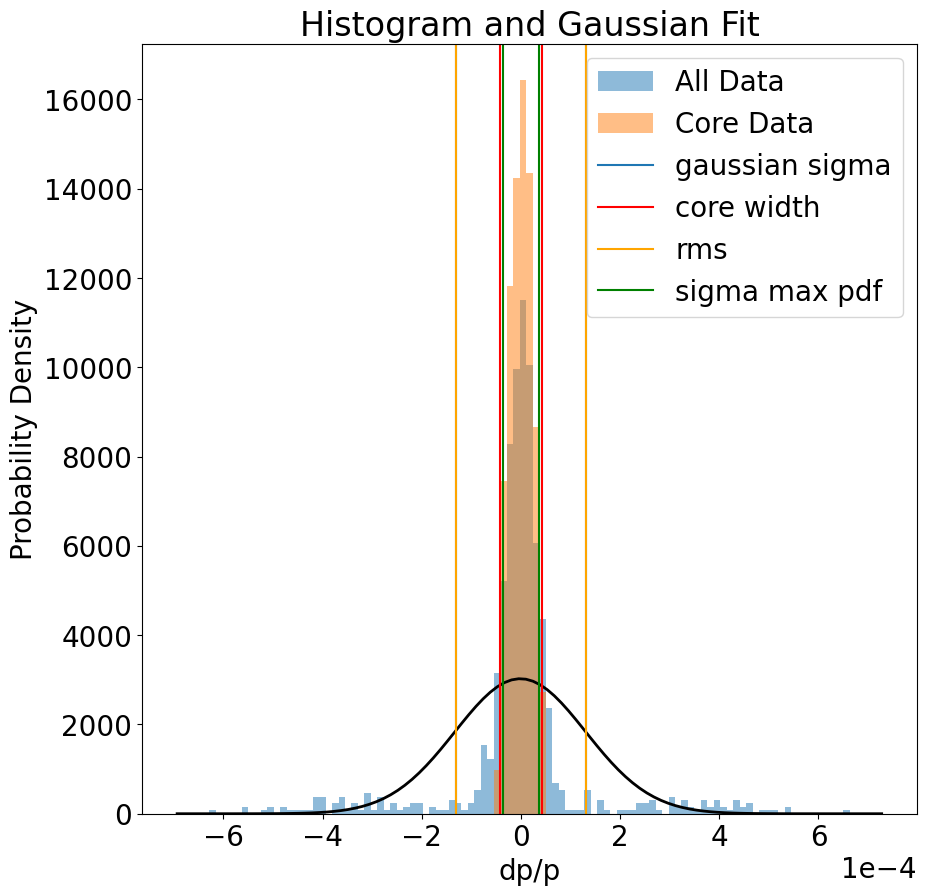

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Assume delta_perc is already defined and delta_perc_final is the last element.
delta_perc_final = delta_perc[-1]

rms=np.std(delta_perc_final)

# Define the core using the 15th and 85th percentiles.
p20, p80 = np.percentile(delta_perc_final, [15, 85])
core = delta_perc_final[(delta_perc_final >= p20) & (delta_perc_final <= p80)]
core_width_val=(p80-p20)/2
# Set up histogram bins.
bins = np.linspace(-2e-4, 2e-4, 100)
bins = np.linspace(min(delta_perc_final), max(delta_perc_final), 100)


####################################################################

counts, bin_edges = np.histogram(delta_perc_final, bins=100, density=True)

# Calculate bin centers.
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# Find the maximum PDF value and corresponding x-value.
max_pdf = counts.max()

# Compute sigma from the formula σ = 1 / (sqrt(2π) * f_max)
sigma = 1.0 / (np.sqrt(2.0 * np.pi) * max_pdf)

print(f"f_max = {max_pdf}")
print(f"sigma = {sigma:.4e}")

# Plot histograms of the full dataset and the core.
plt.figure(figsize=(10, 10))
plt.hist(delta_perc_final, bins=bins, alpha=0.5, label='All Data', density=True)
plt.hist(core, bins=bins, alpha=0.5, label='Core Data', density=True)

# Fit a Gaussian to the core data.
mu, std = norm.fit(delta_perc_final)

# Generate x values for the fitted Gaussian curve.
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mu, std)

# Plot the fitted Gaussian curve.
plt.plot(x, p, 'k', linewidth=2)
plt.xlabel('dp/p')
plt.ylabel('Probability Density')

plt.title('Histogram and Gaussian Fit')
plt.ticklabel_format(axis='x', style='sci', scilimits=(0,0))

plt.axvline(-std,label='gaussian sigma')
plt.axvline(std)

plt.axvline(-core_width_val,color='red',label='core width')
plt.axvline(core_width_val,color='red')

plt.axvline(-rms,color='orange',label='rms')
plt.axvline(rms,color='orange')

plt.axvline(-sigma,color='green',label='sigma max pdf')
plt.axvline(sigma,color='green')

plt.legend()
plt.show()


In [19]:
def extract_core_pdf_threshold(data, threshold=1000):
    """
    Extracts the core of a distribution by keeping points with estimated PDF
    >= max_pdf / threshold. Works with NumPy or CuPy via np interface.

    Parameters
    ----------
    np : module
        The numerical backend (np or cp).
    data : array
        The 1D data array to extract the core from.
    threshold : float, optional
        PDF threshold factor. Points with PDF less than max_pdf / threshold
        will be considered outliers. Default is 1000.

    Returns
    -------
    core_data : array
        1D array of data values that belong to the core.
    """
    if len(data) < 2:
        return data

    # Freedman–Diaconis bin width
    q25, q75 = np.percentile(data, [25, 75])
    iqr = q75 - q25
    bin_width = 2 * iqr * len(data) ** (-1 / 3)
    data_min = float(np.min(data))
    data_max = float(np.max(data))
    if bin_width == 0 or data_max == data_min:
        return data

    n_bins = int(np.maximum(5, np.ceil((data_max - data_min) / bin_width)))
    bin_edges = np.asarray(np.linspace(data_min, data_max, n_bins + 1))
    bin_width = bin_edges[1] - bin_edges[0]

    # Bin index assignment
    indices = np.floor((data - bin_edges[0]) / bin_width).astype(int)
    indices = np.clip(indices, 0, n_bins - 1)

    # Compute PDF manually
    counts = np.zeros(n_bins, dtype=float)
    for i in range(len(data)):
        counts[indices[i]] += 1
    counts = counts / (np.sum(counts) * bin_width)

    max_pdf = np.max(counts)
    print(max_pdf)
    pdf_at_points = counts[indices]
    mask = pdf_at_points >= max_pdf / threshold
    print(mask)
    return data[mask]


def extract_core_mad_fast(data, scale=3.0):
    """
    Very fast core estimator using median and MAD.
    Keeps values within `scale * MAD` of median.
    """
    med = np.median(data)
    mad = np.median(np.abs(data - med))
    threshold = scale * mad * 1.4826  # Convert MAD to sigma for Gaussian
    return data[np.abs(data - med) < threshold]


In [20]:
data = delta_peak[-1]

med = np.median(data)
mad = np.median(np.abs(data - med))
print(med)
print(mad)

1.5140004692160147e-06
2.4429781876667e-05


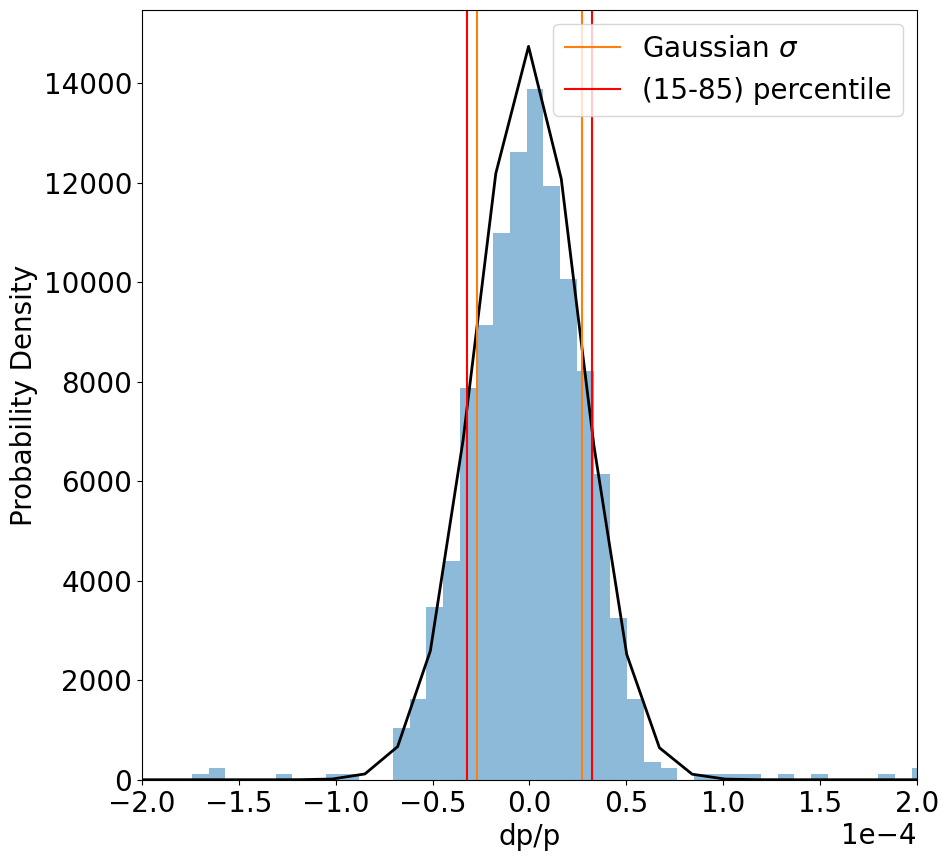

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Assume delta_perc is already defined and delta_perc_final is the last element.
delta_perc_final = delta_old_ibs[-1]
# delta_perc_final = delta_peak[-1]
# delta_perc_final = delta_perc[-1]

rms=np.std(delta_perc_final)

# Define the core using the 15th and 85th percentiles.
p20, p80 = np.percentile(delta_perc_final, [15, 85])
core = delta_perc_final[(delta_perc_final >= p20) & (delta_perc_final <= p80)]
core_width_val=(p80-p20)/2
# Set up histogram bins.

nbins=freedman_diaconis_bins(delta_perc_final)

bins = np.linspace(-2e-4, 2e-4, nbins)
bins = np.linspace(min(delta_perc_final), max(delta_perc_final), nbins)

#core_threshhold=extract_core_pdf_threshold(delta_perc_final,threshold=10)
core_threshhold=extract_core_mad_fast(delta_perc_final, scale=3.0)

core_std=np.std(core_threshhold)

# Plot histograms of the full dataset and the core.
plt.figure(figsize=(10, 10))
plt.hist(delta_perc_final, bins=bins, alpha=0.5, density=True)
# plt.hist(core, bins=bins, alpha=0.5, label='Core Data', density=True)
# plt.hist(core_threshhold, bins=bins, alpha=0.5, label='Core Data', density=True)

# Fit a Gaussian to the core data.
mu, std = norm.fit(core_threshhold)

# Generate x values for the fitted Gaussian curve.
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mu, std)

# Plot the fitted Gaussian curve.
plt.plot(x, p, 'k', linewidth=2)
plt.xlabel('dp/p')
plt.ylabel('Probability Density')
plt.ticklabel_format(axis='x', style='sci', scilimits=(0,0))

plt.axvline(-std,color='C1',label=r'Gaussian $\sigma$')
plt.axvline(std,color='C1')

plt.axvline(-core_width_val,color='red',label='(15-85) percentile')
plt.axvline(core_width_val,color='red')

# plt.axvline(-core_std,color='green',label='core std')
# plt.axvline(core_std,color='green')

# plt.axvline(-rms,color='orange',label='rms')
# plt.axvline(rms,color='orange')


plt.xlim(-2e-4,2e-4)
plt.legend()
plt.show()


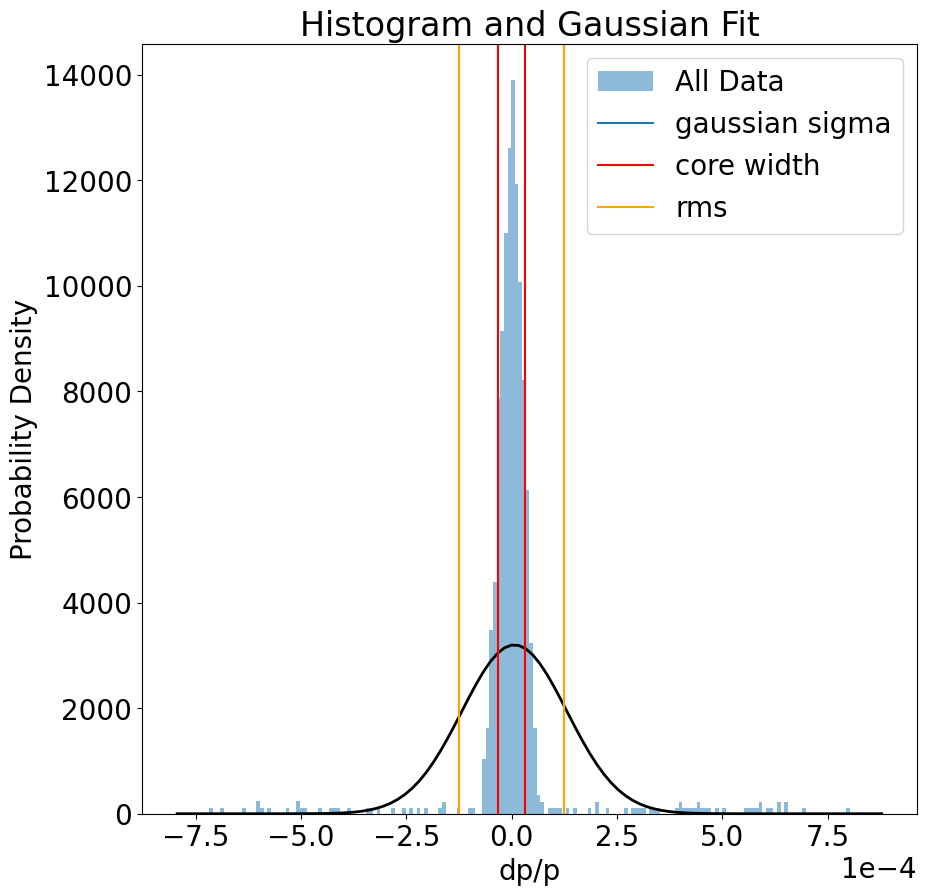

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Assume delta_perc is already defined and delta_perc_final is the last element.
delta_perc_final = delta_old_ibs[-1]
delta_perc_final = delta_perc[-1]
delta_perc_final = delta_old_ibs[-1]

rms=np.std(delta_perc_final)

# Define the core using the 15th and 85th percentiles.
p20, p80 = np.percentile(delta_perc_final, [15, 85])
core = delta_perc_final[(delta_perc_final >= p20) & (delta_perc_final <= p80)]
core_width_val=(p80-p20)/2
# Set up histogram bins.

nbins=freedman_diaconis_bins(delta_perc_final)

bins = np.linspace(-2e-4, 2e-4, nbins)
bins = np.linspace(min(delta_perc_final), max(delta_perc_final), nbins)

#core_threshhold=extract_core_pdf_threshold(delta_perc_final,threshold=10)
core_threshhold=extract_core_mad_fast(delta_perc_final, scale=3.0)

# Plot histograms of the full dataset and the core.
plt.figure(figsize=(10, 10))
plt.hist(delta_perc_final, bins=bins, alpha=0.5, label='All Data', density=True)
# plt.hist(core, bins=bins, alpha=0.5, label='Core Data', density=True)
# plt.hist(core_threshhold, bins=bins, alpha=0.5, label='Core Data', density=True)

# Fit a Gaussian to the core data.
mu, std = norm.fit(delta_perc_final)

# Generate x values for the fitted Gaussian curve.
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mu, std)

# Plot the fitted Gaussian curve.
plt.plot(x, p, 'k', linewidth=2)
plt.xlabel('dp/p')
plt.ylabel('Probability Density')

plt.title('Histogram and Gaussian Fit')
plt.ticklabel_format(axis='x', style='sci', scilimits=(0,0))

plt.axvline(-std,label='gaussian sigma')
plt.axvline(std)

plt.axvline(-core_width_val,color='red',label='core width')
plt.axvline(core_width_val,color='red')

plt.axvline(-rms,color='orange',label='rms')
plt.axvline(rms,color='orange')

plt.legend()
plt.show()


In [23]:
len(core_threshhold)

926

custom ibs 2

In [24]:
data_output= np.load(f'results/IBS_custom/{ion_loop.name}_output.npz')

delta_output = data_output['delta']
emittance_x_output = data_output['emittance_x']
time_output = data_output['time']
rms_dp_p_output = np.std(delta_output, axis=1)


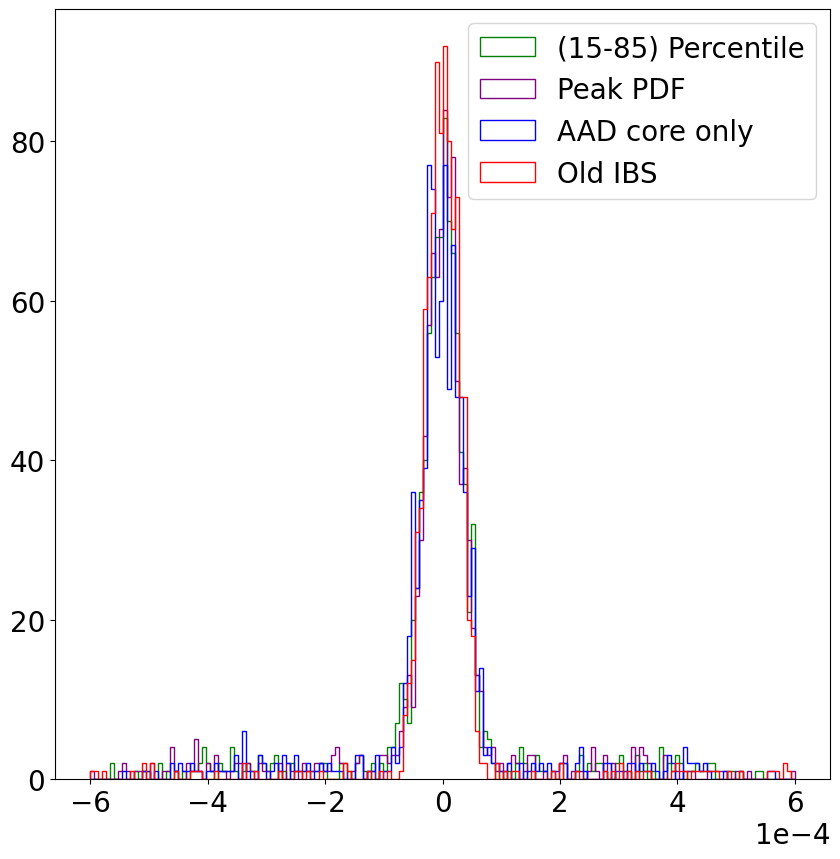

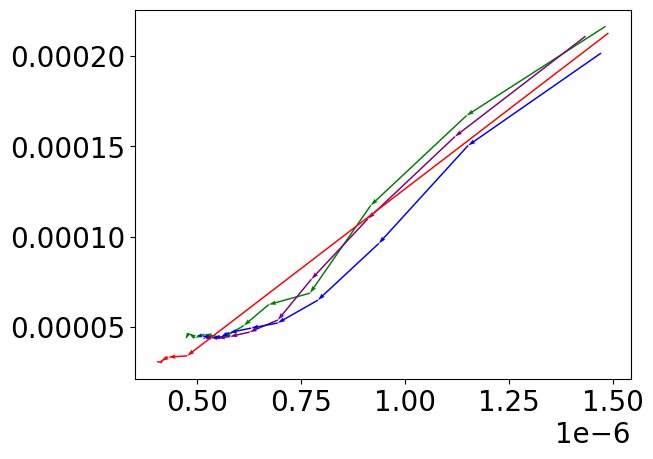

In [25]:
idx_to_look_at = -1
bins=np.linspace(-6e-4,6e-4,nbins)
plt.figure(figsize=(10,10))
# plt.hist(delta_full_ibs[idx_to_look_at], 100,histtype='step',density=True,label='sigma full ibs')
# plt.hist(delta_old_ibs[idx_to_look_at], 100,histtype='step',density=True,label='sigma old ibs')
# plt.hist(delta_custom[idx_to_look_at],100,histtype='step',density=True,label='sigma only long. ibs')

#plt.hist(delta_no_ibs[idx_to_look_at],bins,histtype='step',color='yellow',density=False,label=f'no ibs {np.std(delta_no_ibs[idx_to_look_at]):.2e}')
#plt.hist(delta_old_ibs[idx_to_look_at],bins,histtype='step',color='black',density=False,label=f'old ibs {np.std(delta_old_ibs[idx_to_look_at]):.2e}')
#plt.hist(delta_20_80[idx_to_look_at],bins,histtype='step',color='blue',density=False,label=f'20/80 ibs {np.std(delta_20_80[idx_to_look_at]):.2e}')
#plt.hist(delta_30_70[idx_to_look_at],bins,histtype='step',color='red',density=False,label=f'30/70 ibs {np.std(delta_30_70[idx_to_look_at]):.2e}')

plt.hist(delta_perc[idx_to_look_at],bins,histtype='step',color='green',density=False,label='(15-85) Percentile')
plt.hist(delta_peak[idx_to_look_at],bins,histtype='step',color='purple',density=False, label='Peak PDF')
plt.hist(delta_peter[idx_to_look_at],bins,histtype='step',color='blue',density=False, label='AAD core only')
plt.hist(delta_old_ibs[idx_to_look_at],bins,histtype='step',color='red',density=False, label='Old IBS')

#plt.xlim([-0.00025,0.00025])
plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
plt.legend()
plt.show()

plot_quiver(emittance_x_perc, core_width_perc, time_perc, 'green', label='(15-85) Percentile') 
plot_quiver(emittance_x_peak, core_width_peak, time_peak, 'purple', label='Peak PDF') 

plot_quiver(emittance_x_peter, core_width_peter, time_peter, 'blue', label='AAD core only') 

plot_quiver(emittance_x_old_ibs, core_width_old_ibs, time_old_ibs, 'red', label='Old IBS') 

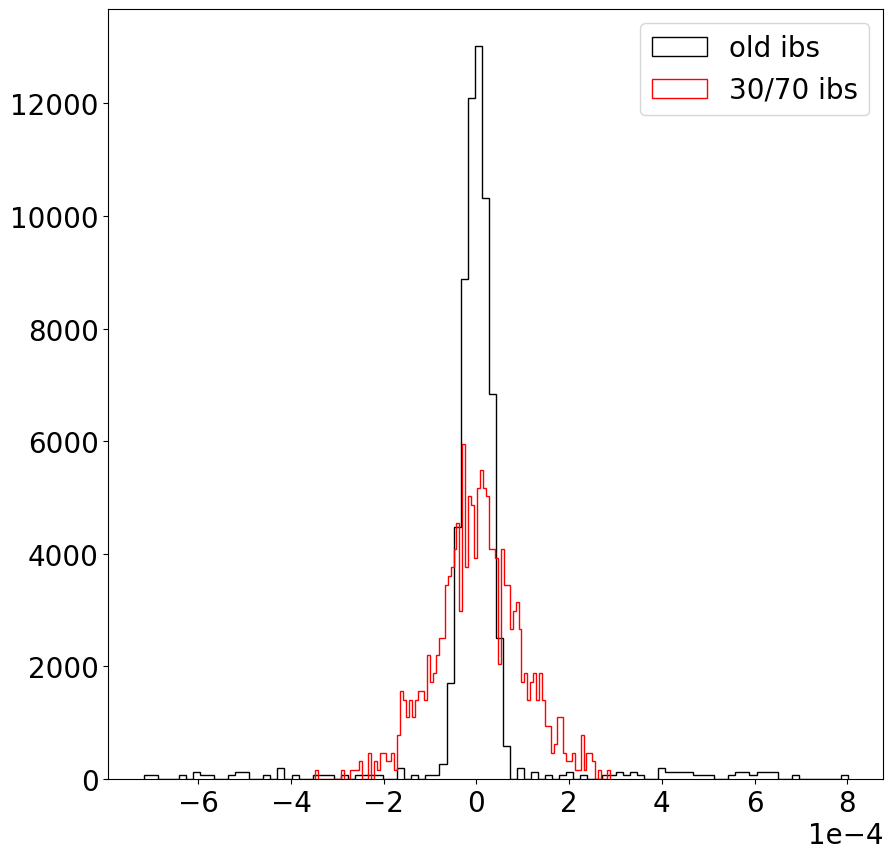

In [26]:
plt.figure(figsize=(10,10))
# plt.hist(delta_full_ibs[idx_to_look_at], 100,histtype='step',density=True,label='sigma full ibs')
# plt.hist(delta_old_ibs[idx_to_look_at], 100,histtype='step',density=True,label='sigma old ibs')
# plt.hist(delta_custom[idx_to_look_at],100,histtype='step',density=True,label='sigma only long. ibs')
plt.hist(delta_old_ibs[idx_to_look_at],100,histtype='step',color='black',density=True,label='old ibs')
# plt.hist(delta_10_90[idx_to_look_at],100,histtype='step',color='orange',density=True,label='10/90 ibs')
# plt.hist(delta_20_80[idx_to_look_at],100,histtype='step',color='blue',density=True,label='20/80 ibs')
plt.hist(delta_30_70[idx_to_look_at],100,histtype='step',color='red',density=True,label='30/70 ibs')
#plt.xlim([-0.00025,0.00025])
plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
plt.legend()
plt.show()

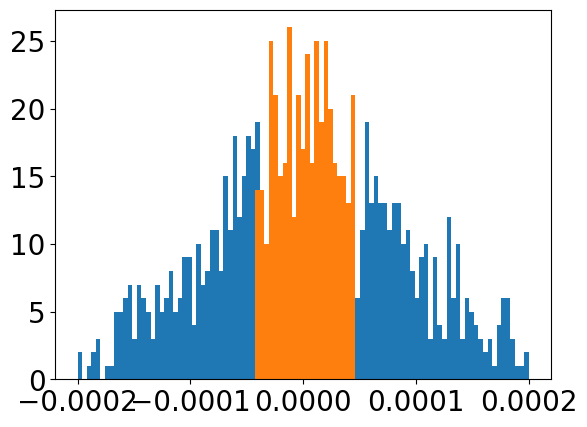

In [27]:
delta_30_70_final=delta_30_70[-1]

p20, p80 = np.percentile(delta_30_70_final, [30, 70])
core = delta_30_70_final[(delta_30_70_final >= p20) & (delta_30_70_final <= p80)]

bins=np.linspace(-2e-4,2e-4,100)
plt.figure()
plt.hist(delta_30_70_final,bins=bins)
plt.hist(core,bins=bins)
plt.show()

In [28]:
print(rms_dp_p_full_ibs[-1])
print(rms_dp_p_old_ibs[-1])

0.00015511030187011614
0.00012470208702294516


with borders

In [29]:
# def core_width_func(data):
#     core_width_list=[]
#     delta=data['delta']
#     state=data['state']
#     for turn in range(delta.shape[0]):
#         data=delta[turn]
#         scale=3
#         threshold = scale * mad * 1.4826  # Convert MAD to sigma
#         data_core = data[np.abs(data - med) < threshold]
#         core_width=np.std(data_core)
#         core_width_list.append(core_width)
#     return core_width_list

In [30]:
def core_width_func(data):
    core_width_list=[]
    delta=data['delta']
    state=data['state']
    for turn in range(delta.shape[0]):
        data=delta[turn]
        data_core=extract_core_mad_fast(data, scale=3.0)
        core_width=np.std(data_core)
        core_width_list.append(core_width)
    return core_width_list


# def core_width_func(data):
#     core_width_list=[]
#     delta=data['delta']
#     state=data['state']
#     for turn in range(delta.shape[0]):
#         data=delta[turn]
#         data_core=extract_core_mad_fast(data, scale=3.0)
#         core_width=(max(data_core)-min(data_core))/2
#         core_width_list.append(core_width)
#     return core_width_list

In [31]:
# from tqdm import tqdm
# from matplotlib.patches import Patch
# from matplotlib.lines import Line2D

# plt.figure(figsize=(12, 8))
# plt.rcParams.update({'font.size': 20})

# cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']

# for i, ion_loop in tqdm(enumerate([calcium])):    

#     core_width_peter2=core_width_func(data_peter)

#     emittance_x_values = emittance_x_custom[:]
#     rms_dp_p_values = rms_dp_p_custom[:]   
    
# # plot_quiver(emittance_x_custom, sigma_list_custom, time_custom, 'orange', label='sigma only long. ibs')
# # plot_quiver(emittance_x_old_ibs, sigma_list_old_ibs, time_old_ibs, 'blue', label='sigma old ibs')
# # plot_quiver(emittance_x_full_ibs, sigma_list_full_ibs, time_full_ibs, 'red', label='sigma full ibs')     
  
# # plot_quiver(emittance_x_custom, rms_dp_p_custom, time_custom, 'black', label='only long. gaussian ibs')

# # plot_quiver(emittance_x_full_ibs, rms_dp_p_full_ibs, time_full_ibs, 'blue', label='full gaussian ibs')

# # plot_quiver(emittance_x_old_ibs, rms_dp_p_old_ibs, time_old_ibs, 'black', label='old ibs')
# # plot_quiver(emittance_x_10_90, rms_dp_p_10_90, time_10_90, 'orange', label='10/90 IBS') 
# # plot_quiver(emittance_x_20_80, rms_dp_p_20_80, time_20_80, 'blue', label='20/80 IBS') 
# # plot_quiver(emittance_x_30_70, rms_dp_p_30_70, time_30_70, 'red', label='30/70 IBS') 


# #plot_quiver(emittance_x_old_ibs, core_width_old_ibs, time_old_ibs, 'black', label='old ibs')
# # plot_quiver(emittance_x_full_ibs, rms_dp_p_full_ibs, time_full_ibs, 'blue', label='full gaussian ibs') 
# # plot_quiver(emittance_x_10_90, core_width_10_90, time_10_90, 'orange', label='RMS of (10/90)') 
# # plot_quiver(emittance_x_20_80, core_width_20_80, time_20_80, 'blue', label='RMS of (20/80)') 
# # plot_quiver(emittance_x_30_70, core_width_30_70, time_30_70, 'red', label='RMS of (30/70)')

# #plot_quiver(emittance_x_perc, core_width_perc, time_perc, 'green', label='(15-85) Percentile') 
# #plot_quiver(emittance_x_peak, core_width_peak, time_perc, 'purple', label='Peak PDF') 

# # plot_quiver(emittance_x_peter, core_width_peter, time_peter, 'C42', label='peter IBS') 
# ###########################################################################################################


# plot_quiver(emittance_x_peter, core_width_peter, time_peter, color='C42', label='peter IBS') 

# ###############################################################################################################
# data = np.load(f'../results/IBS_bunched/{ion_loop.name}.npz')

# growth_rates_2d_x = data['growth_rates_2d_x']
# growth_rates_2d_y = data['growth_rates_2d_y']
# growth_rates_2d_z = 0.5*data['growth_rates_2d_z']
# #max_growth_rate=np.maximum(growth_rates_2d_x,growth_rates_2d_y,growth_rates_2d_z)
# # max_growth_rate = np.maximum.reduce([growth_rates_2d_x, growth_rates_2d_y, growth_rates_2d_z])
# # max_growth_rate=growth_rates_2d_x
# sig_delta_list = data['sig_delta_list']
# n_emitt_list = data['n_emitt_list']
# total_intensity = data['total_intensity']

# loaded_data = np.load(f'../results/optimal_laser_x/{ion_loop.name}.npz')
# transverse_growth_rate_list = loaded_data['transverse_growth_rate_list']
# longitudinal_growth_rate_list=loaded_data['longitudinal_growth_rate_dp_p_list']
# #longitudinal_growth_rate_list=loaded_data['longitudinal_growth_rate_emittance_list']
# laser_x_list = loaded_data['laser_x_list']

# min_transverse_index = np.argmin(transverse_growth_rate_list)
# min_longitudinal_index = np.argmin(longitudinal_growth_rate_list)

# laser_position_index = 74
# laser_position_index = min_transverse_index
# laser_offset = laser_x_list[laser_position_index]
# threshold_longitudinal = -longitudinal_growth_rate_list[min_transverse_index]
# threshold_transverse = -min(transverse_growth_rate_list)

# plt.contour(n_emitt_list, sig_delta_list, growth_rates_2d_x, levels=[threshold_transverse, np.inf],
#             colors=cycle[0], linewidths=2)

# plt.contour(n_emitt_list, sig_delta_list, growth_rates_2d_z, levels=[threshold_longitudinal],
#             colors=cycle[0], linestyles='--', linewidths=2)

# ###################################################################################################

# data = np.load(f'../results/IBS_bunched_core/{ion_loop.name}.npz')

# growth_rates_2d_x = data['growth_rates_2d_x']
# growth_rates_2d_y = data['growth_rates_2d_y']
# growth_rates_2d_z = 0.5*data['growth_rates_2d_z']

# sig_delta_list = data['sig_delta_list']
# n_emitt_list = data['n_emitt_list']

# plt.contour(n_emitt_list, sig_delta_list, growth_rates_2d_x, levels=[threshold_transverse, np.inf],
#             colors=cycle[1], linewidths=2)

# plt.contour(n_emitt_list, sig_delta_list, growth_rates_2d_z, levels=[threshold_longitudinal],
#             colors=cycle[1], linestyles='--', linewidths=2)

# #plt.scatter(injection_nemitt, injection_dp_p, color='red', label='Initial condition')

# # plt.xlim([0, 1.6*1e-6])
# # plt.ylim([0, 3*1e-4])
# plt.xlabel('Normalized emittance $\\epsilon_n$ [rad m]', fontsize=20)
# plt.ylabel('RMS dp/p', fontsize=20)
# plt.ylabel('(15-85) Percentile', fontsize=20)
# plt.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))

# # plt.legend(handles=[
# #     Line2D([0], [0], linestyle='-', color='black',  label='rms dp_p'),
# #     Line2D([0], [0], linestyle='--', color='orange', label='gaus sigma'),
          
# # ], loc='lower right')

# plt.legend(handles=[
#     Line2D([0], [0], linestyle='-', color='black',  label='rms dp_p'),
#     Line2D([0], [0], linestyle='--', color='orange', label='gaus sigma'),
          
# ], loc='lower right')

# plt.legend(loc='upper left')
# plt.xlim(0,2*1e-6)
# plt.tight_layout()
# #plt.savefig('figures/Equilibrium_emittance.png', dpi=300)
# plt.show()

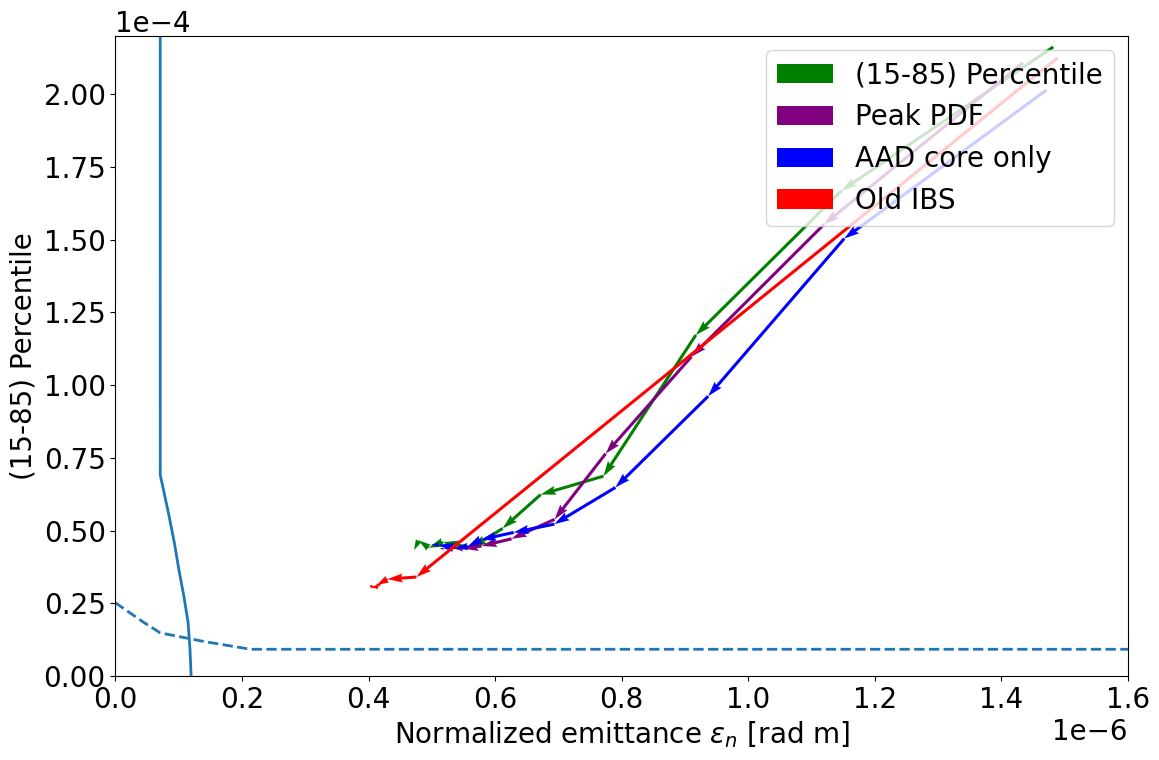

In [32]:
from tqdm import tqdm
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

plt.figure(figsize=(12, 8))
plt.rcParams.update({'font.size': 20})

cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']

  
    
    
# plot_quiver(emittance_x_custom, sigma_list_custom, time_custom, 'orange', label='sigma only long. ibs')
# plot_quiver(emittance_x_old_ibs, sigma_list_old_ibs, time_old_ibs, 'blue', label='sigma old ibs')
# plot_quiver(emittance_x_full_ibs, sigma_list_full_ibs, time_full_ibs, 'red', label='sigma full ibs')     
  
# plot_quiver(emittance_x_custom, rms_dp_p_custom, time_custom, 'black', label='only long. gaussian ibs')

# plot_quiver(emittance_x_full_ibs, rms_dp_p_full_ibs, time_full_ibs, 'blue', label='full gaussian ibs')

# plot_quiver(emittance_x_old_ibs, rms_dp_p_old_ibs, time_old_ibs, 'black', label='old ibs')
# plot_quiver(emittance_x_10_90, rms_dp_p_10_90, time_10_90, 'orange', label='10/90 IBS') 
# plot_quiver(emittance_x_20_80, rms_dp_p_20_80, time_20_80, 'blue', label='20/80 IBS') 
# plot_quiver(emittance_x_30_70, rms_dp_p_30_70, time_30_70, 'red', label='30/70 IBS') 


#plot_quiver(emittance_x_old_ibs, core_width_old_ibs, time_old_ibs, 'black', label='old ibs')
# plot_quiver(emittance_x_full_ibs, rms_dp_p_full_ibs, time_full_ibs, 'blue', label='full gaussian ibs') 
# plot_quiver(emittance_x_10_90, core_width_10_90, time_10_90, 'orange', label='RMS of (10/90)') 
# plot_quiver(emittance_x_20_80, core_width_20_80, time_20_80, 'blue', label='RMS of (20/80)') 
# plot_quiver(emittance_x_30_70, core_width_30_70, time_30_70, 'red', label='RMS of (30/70)')

plot_quiver(emittance_x_perc, core_width_perc, time_perc, 'green', label='(15-85) Percentile') 
plot_quiver(emittance_x_peak, core_width_peak, time_peak, 'purple', label='Peak PDF') 

plot_quiver(emittance_x_peter, core_width_peter, time_peter, 'blue', label='AAD core only') 

plot_quiver(emittance_x_old_ibs, core_width_old_ibs, time_old_ibs, 'red', label='Old IBS') 


###########################################################################################################


#plot_quiver(emittance_x_peter, core_width_peter, time_peter, color='C42', label='peter IBS') 

###############################################################################################################
data = np.load(f'../results/IBS_bunched_core/{ion_loop.name}.npz')

growth_rates_2d_x = data['growth_rates_2d_x']
growth_rates_2d_y = data['growth_rates_2d_y']
growth_rates_2d_z = 0.5*data['growth_rates_2d_z']
#max_growth_rate=np.maximum(growth_rates_2d_x,growth_rates_2d_y,growth_rates_2d_z)
# max_growth_rate = np.maximum.reduce([growth_rates_2d_x, growth_rates_2d_y, growth_rates_2d_z])
# max_growth_rate=growth_rates_2d_x
sig_delta_list = data['sig_delta_list']
n_emitt_list = data['n_emitt_list']
total_intensity = data['total_intensity']

loaded_data = np.load(f'../results/optimal_laser_x/{ion_loop.name}.npz')
transverse_growth_rate_list = loaded_data['transverse_growth_rate_list']
longitudinal_growth_rate_list=loaded_data['longitudinal_growth_rate_dp_p_list']
#longitudinal_growth_rate_list=loaded_data['longitudinal_growth_rate_emittance_list']
laser_x_list = loaded_data['laser_x_list']

min_transverse_index = np.argmin(transverse_growth_rate_list)
min_longitudinal_index = np.argmin(longitudinal_growth_rate_list)

laser_position_index = 74
laser_position_index = min_transverse_index
laser_offset = laser_x_list[laser_position_index]
threshold_longitudinal = -longitudinal_growth_rate_list[min_transverse_index]
threshold_transverse = -min(transverse_growth_rate_list)

threshold_longitudinal=1.75

plt.contour(n_emitt_list, sig_delta_list, growth_rates_2d_x, levels=[threshold_transverse, np.inf],
            colors=cycle[0], linewidths=2)

plt.contour(n_emitt_list, sig_delta_list, growth_rates_2d_z, levels=[threshold_longitudinal],
            colors=cycle[0], linestyles='--', linewidths=2)

###################################################################################################

data = np.load(f'../results/IBS_bunched_core/{ion_loop.name}.npz')

growth_rates_2d_x = data['growth_rates_2d_x']
growth_rates_2d_y = data['growth_rates_2d_y']
growth_rates_2d_z = 0.5*data['growth_rates_2d_z']

sig_delta_list = data['sig_delta_list']
n_emitt_list = data['n_emitt_list']

# plt.contour(n_emitt_list, sig_delta_list, growth_rates_2d_x, levels=[threshold_transverse, np.inf],
#             colors=cycle[1], linewidths=2)

# plt.contour(n_emitt_list, sig_delta_list, growth_rates_2d_z, levels=[threshold_longitudinal],
#             colors=cycle[1], linestyles='--', linewidths=2)

#plt.scatter(injection_nemitt, injection_dp_p, color='red', label='Initial condition')

# plt.xlim([0, 1.6*1e-6])
# plt.ylim([0, 3*1e-4])
plt.xlabel('Normalized emittance $\\epsilon_n$ [rad m]', fontsize=20)
plt.ylabel('RMS dp/p', fontsize=20)
plt.ylabel('(15-85) Percentile', fontsize=20)
plt.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))

# plt.legend(handles=[
#     Line2D([0], [0], linestyle='-', color='black',  label='rms dp_p'),
#     Line2D([0], [0], linestyle='--', color='orange', label='gaus sigma'),
          
# ], loc='lower right')

# plt.legend(handles=[
#     Line2D([0], [0], linestyle='--', color='C0',  label='Old equilibrium'),
#     Line2D([0], [0], linestyle='--', color='C1', label='85% equilibrium'),
          
# ], loc='upper left')

plt.legend()
plt.ylim(0,2.2*1e-4)
plt.xlim(0,1.6*1e-6)

plt.tight_layout()
#plt.savefig('figures/Equilibrium_emittance.png', dpi=300)
plt.show()

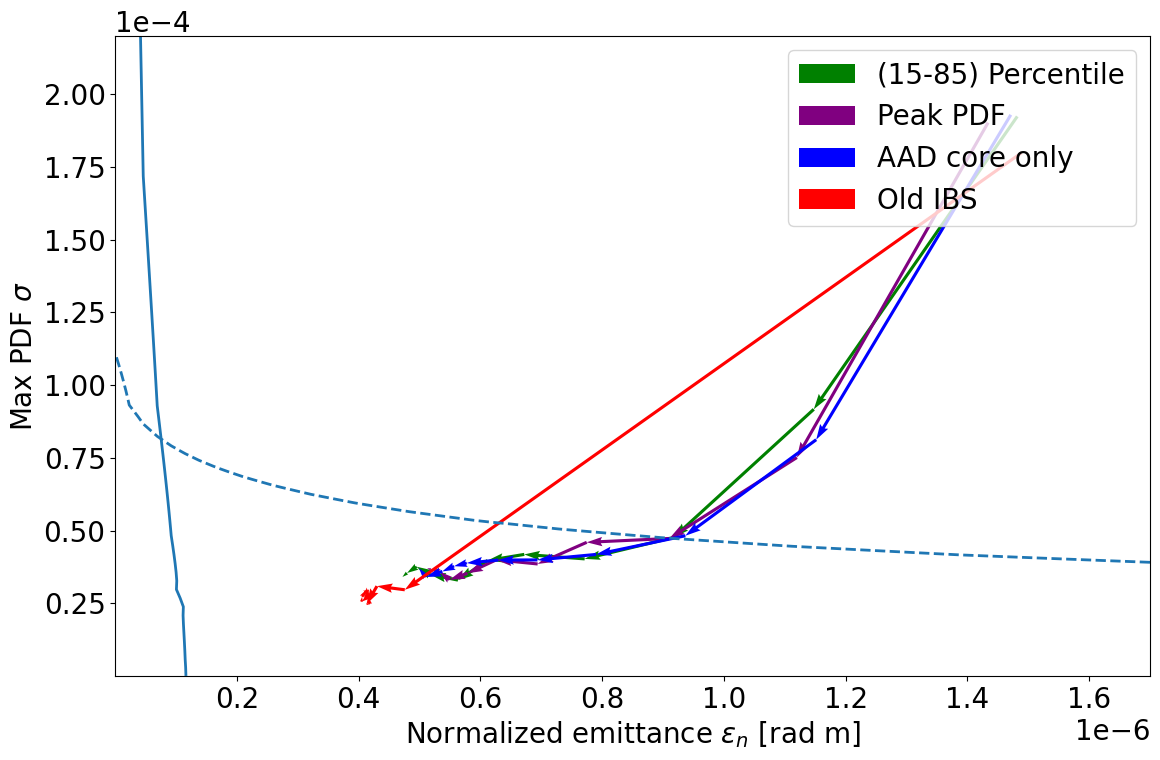

In [33]:
from tqdm import tqdm
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

plt.figure(figsize=(12, 8))
plt.rcParams.update({'font.size': 20})

cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']


plot_quiver(emittance_x_perc, max_pdf_perc, time_perc, 'green', label='(15-85) Percentile') 
plot_quiver(emittance_x_peak, max_pdf_peak, time_peak, 'purple', label='Peak PDF') 

plot_quiver(emittance_x_peter, max_pdf_peter, time_peter, 'blue', label='AAD core only') 

plot_quiver(emittance_x_old_ibs, max_pdf_old_ibs, time_old_ibs, 'red', label='Old IBS') 


###########################################################################################################


#plot_quiver(emittance_x_peter, core_width_peter, time_peter, color='C42', label='peter IBS') 

###############################################################################################################
data = np.load(f'../results/IBS_bunched/{ion_loop.name}.npz')

growth_rates_2d_x = data['growth_rates_2d_x']
growth_rates_2d_y = data['growth_rates_2d_y']
growth_rates_2d_z = 0.5*data['growth_rates_2d_z']
#max_growth_rate=np.maximum(growth_rates_2d_x,growth_rates_2d_y,growth_rates_2d_z)
# max_growth_rate = np.maximum.reduce([growth_rates_2d_x, growth_rates_2d_y, growth_rates_2d_z])
# max_growth_rate=growth_rates_2d_x
sig_delta_list = data['sig_delta_list']
n_emitt_list = data['n_emitt_list']
total_intensity = data['total_intensity']

loaded_data = np.load(f'../results/optimal_laser_x/{ion_loop.name}.npz')
transverse_growth_rate_list = loaded_data['transverse_growth_rate_list']
longitudinal_growth_rate_list=loaded_data['longitudinal_growth_rate_dp_p_list']
#longitudinal_growth_rate_list=loaded_data['longitudinal_growth_rate_emittance_list']
laser_x_list = loaded_data['laser_x_list']

min_transverse_index = np.argmin(transverse_growth_rate_list)
min_longitudinal_index = np.argmin(longitudinal_growth_rate_list)

laser_position_index = 74
laser_position_index = min_transverse_index
laser_offset = laser_x_list[laser_position_index]
threshold_longitudinal = -longitudinal_growth_rate_list[min_transverse_index]
threshold_transverse = -min(transverse_growth_rate_list)

plt.contour(n_emitt_list, sig_delta_list, growth_rates_2d_x, levels=[threshold_transverse, np.inf],
            colors=cycle[0], linewidths=2)

plt.contour(n_emitt_list, sig_delta_list, growth_rates_2d_z, levels=[threshold_longitudinal],
            colors=cycle[0], linestyles='--', linewidths=2)

###################################################################################################

data = np.load(f'../results/IBS_bunched_core/{ion_loop.name}.npz')

growth_rates_2d_x = data['growth_rates_2d_x']
growth_rates_2d_y = data['growth_rates_2d_y']
growth_rates_2d_z = 0.5*data['growth_rates_2d_z']

sig_delta_list = data['sig_delta_list']
n_emitt_list = data['n_emitt_list']

# plt.contour(n_emitt_list, sig_delta_list, growth_rates_2d_x, levels=[threshold_transverse, np.inf],
#             colors=cycle[1], linewidths=2)

# plt.contour(n_emitt_list, sig_delta_list, growth_rates_2d_z, levels=[threshold_longitudinal],
#             colors=cycle[1], linestyles='--', linewidths=2)

#plt.scatter(injection_nemitt, injection_dp_p, color='red', label='Initial condition')

# plt.xlim([0, 1.6*1e-6])
# plt.ylim([0, 3*1e-4])
plt.xlabel('Normalized emittance $\\epsilon_n$ [rad m]', fontsize=20)
plt.ylabel('RMS dp/p', fontsize=20)
plt.ylabel(r'Max PDF $\sigma$', fontsize=20)
plt.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))

# plt.legend(handles=[
#     Line2D([0], [0], linestyle='-', color='black',  label='rms dp_p'),
#     Line2D([0], [0], linestyle='--', color='orange', label='gaus sigma'),
          
# ], loc='lower right')

# plt.legend(handles=[
#     Line2D([0], [0], linestyle='--', color='C0',  label='Old equilibrium'),
#     Line2D([0], [0], linestyle='--', color='C1', label='85% equilibrium'),
          
# ], loc='upper left')

plt.legend()

# plt.xlim(0,2*1e-6)
plt.tight_layout()
#plt.savefig('figures/Equilibrium_emittance.png', dpi=300)
plt.show()

In [34]:
np.argmin(time_old_ibs-20)

np.int64(0)

0.0005586636796005018


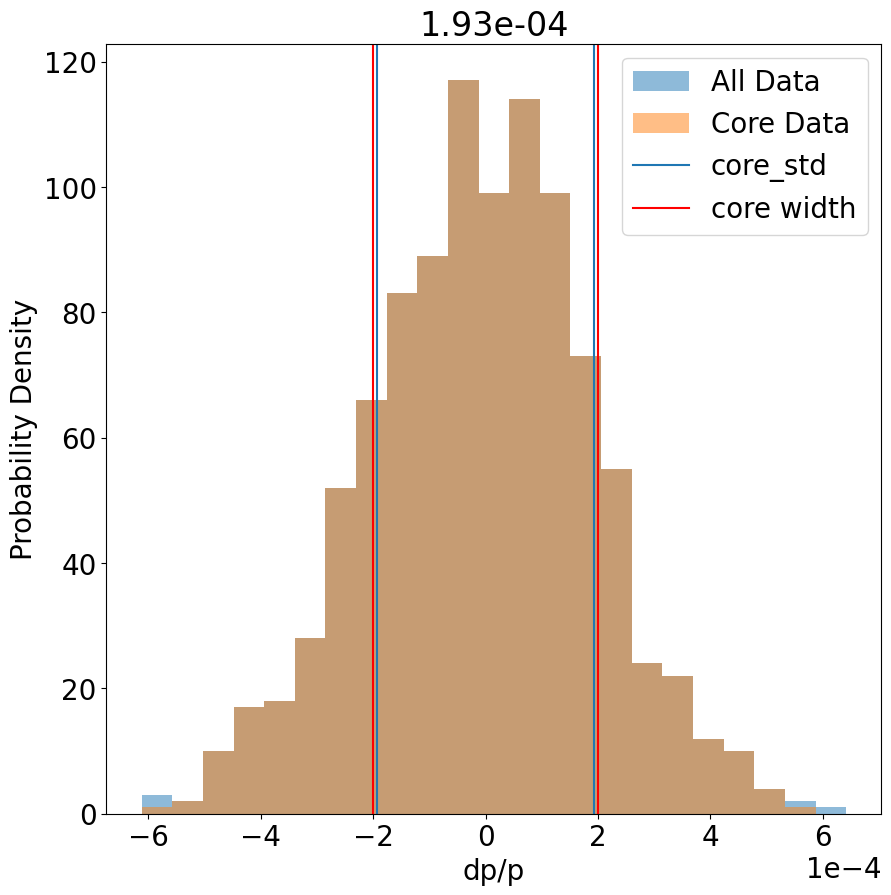

In [35]:
delta_perc_final=delta_peter[0]


nbins=freedman_diaconis_bins(delta_perc_final)

bins = np.linspace(min(delta_perc_final), max(delta_perc_final), nbins)

#core_threshhold=extract_core_pdf_threshold(delta_perc_final,threshold=10)
core_threshhold=extract_core_mad_fast(delta_perc_final, scale=3.0)

len_core =(max(core_threshhold)-min(core_threshhold))/2
print(len_core)

p20, p80 = np.percentile(core_threshhold, [15, 85])
core_width_val=(p80-p20)/2

# Plot histograms of the full dataset and the core.
plt.figure(figsize=(10, 10))
plt.hist(delta_perc_final, bins=bins, alpha=0.5, label='All Data', density=False)
# plt.hist(core, bins=bins, alpha=0.5, label='Core Data', density=True)
plt.hist(core_threshhold, bins=bins, alpha=0.5, label='Core Data', density=False)


core_std=np.std(core_threshhold)
# Fit a Gaussian to the core data.
mu, std = norm.fit(core_threshhold)

# Generate x values for the fitted Gaussian curve.
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mu, std)

# Plot the fitted Gaussian curve.
# plt.plot(x, p, 'k', linewidth=2)
plt.xlabel('dp/p')
plt.ylabel('Probability Density')

plt.title(f'{core_std:.2e}')
plt.ticklabel_format(axis='x', style='sci', scilimits=(0,0))

plt.axvline(-core_std,label='core_std')
plt.axvline(core_std)

plt.axvline(-core_width_val,color='red',label='core width')
plt.axvline(core_width_val,color='red')

# plt.axvline(-rms,color='orange',label='rms')
# plt.axvline(rms,color='orange')

plt.legend()
plt.show()


mad 

0.00011784608879022995


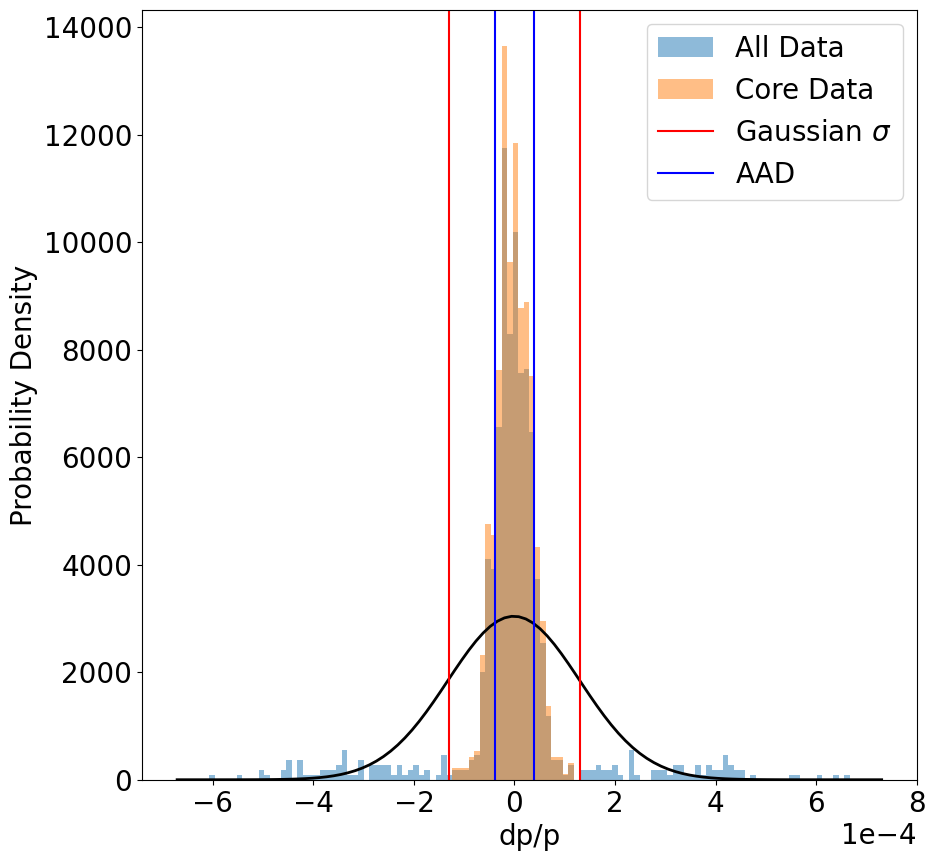

In [36]:
delta_perc_final=delta_peter[-1]


nbins=freedman_diaconis_bins(delta_perc_final)

bins = np.linspace(min(delta_perc_final), max(delta_perc_final), nbins)

#core_threshhold=extract_core_pdf_threshold(delta_perc_final,threshold=10)
core_threshhold=extract_core_mad_fast(delta_perc_final, scale=3.0)

scale=1
med = np.median(delta_perc_final)
mad = np.median(np.abs(delta_perc_final - med))
threshold = scale * mad * 1.4  # Convert MAD to sigma from Ggaussian

len_core =(max(core_threshhold)-min(core_threshhold))/2
print(len_core)

p20, p80 = np.percentile(core_threshhold, [15, 85])
core_width_val=(p80-p20)/2

# Plot histograms of the full dataset and the core.
plt.figure(figsize=(10, 10))
plt.hist(delta_perc_final, bins=bins, alpha=0.5, label='All Data', density=True)
# plt.hist(core, bins=bins, alpha=0.5, label='Core Data', density=True)
plt.hist(core_threshhold, bins=bins, alpha=0.5, label='Core Data', density=True)


core_std=np.std(core_threshhold)
# Fit a Gaussian to the core data.
mu, std = norm.fit(delta_perc_final)

# Generate x values for the fitted Gaussian curve.
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mu, std)

# Plot the fitted Gaussian curve.
plt.plot(x, p, 'k', linewidth=2)
plt.xlabel('dp/p')
plt.ylabel('Probability Density')

#plt.title(f'{core_std:.2e}')
plt.ticklabel_format(axis='x', style='sci', scilimits=(0,0))

plt.axvline(-std,color='red',label=r'Gaussian $\sigma$')
plt.axvline(std,color='red')

plt.axvline(-threshold,color='blue',label='AAD')
plt.axvline(threshold,color='blue')

# plt.axvline(-core_width_val,color='red',label='core width')
# plt.axvline(core_width_val,color='red')

# plt.axvline(-rms,color='orange',label='rms')
# plt.axvline(rms,color='orange')

plt.legend()
plt.show()


In [37]:
x=data_10_90['x']

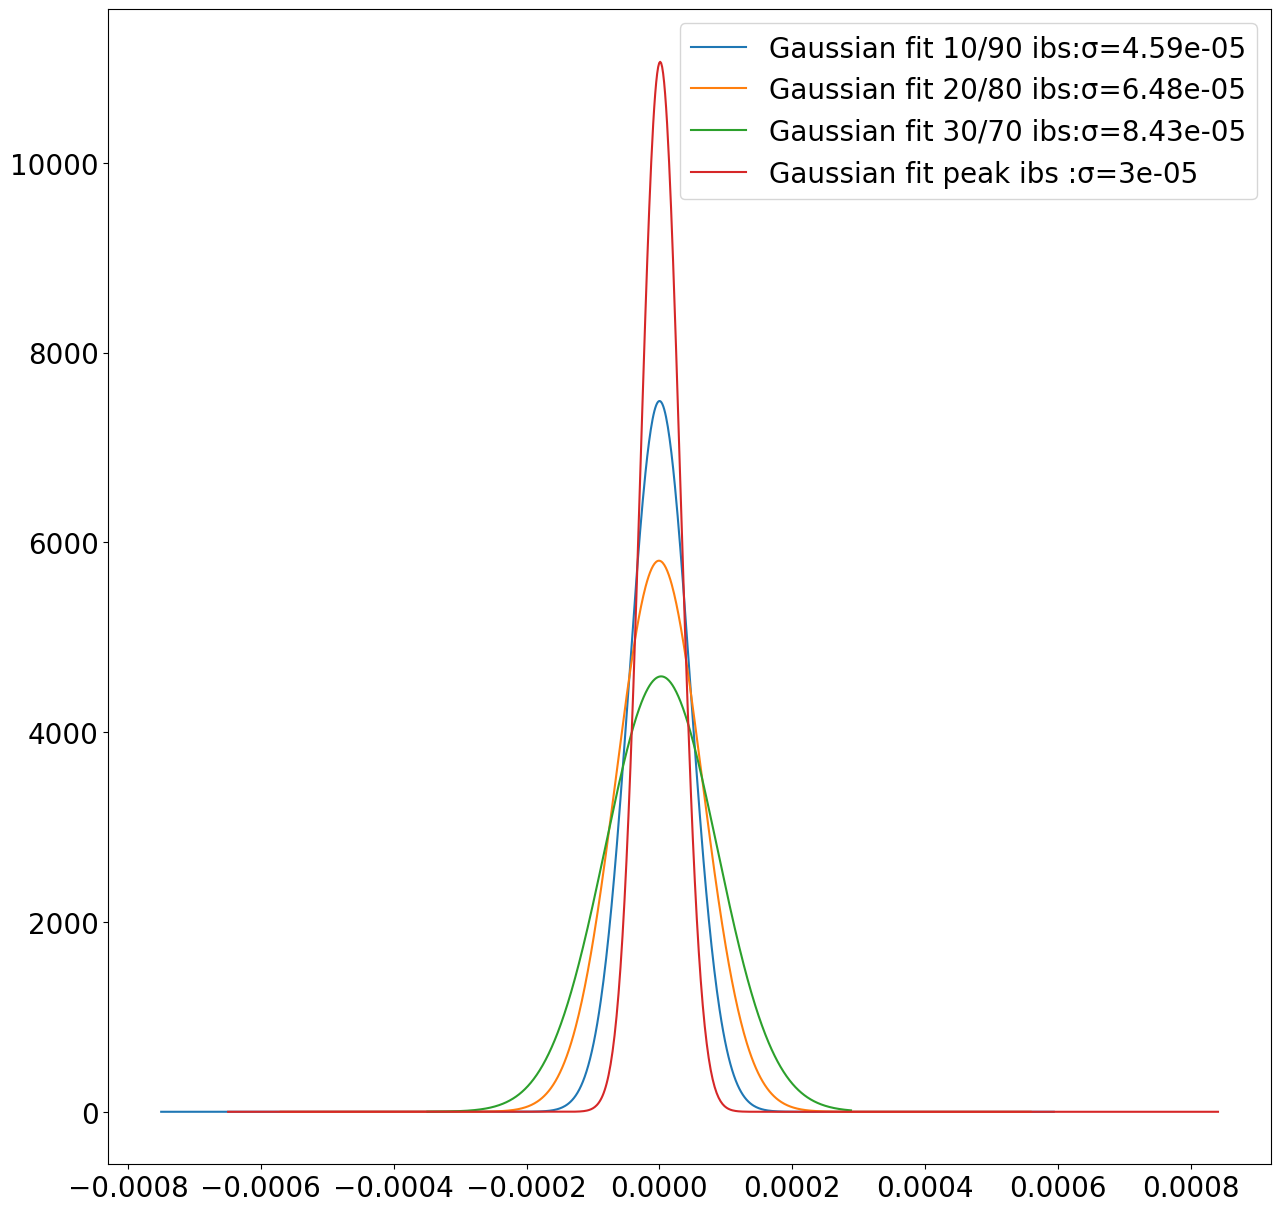

In [38]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Define the Gaussian function.
def gaussian(x, mu, sigma, amplitude):
    return amplitude * np.exp(-((x - mu)**2) / (2 * sigma**2))

# Create a dictionary for your datasets.
datasets = {
    '10/90 ibs': delta_10_90[idx_to_look_at],
    '20/80 ibs': delta_20_80[idx_to_look_at],
    '30/70 ibs': delta_30_70[idx_to_look_at],
    'peak ibs ': delta_peak[idx_to_look_at],
}

plt.figure(figsize=(15, 15))

for label, data in datasets.items():
    # Compute the histogram without plotting it.
    counts, bins = np.histogram(data, bins=100, density=True)
    
    # Compute the bin centers from the bin edges.
    bin_centers = (bins[:-1] + bins[1:]) / 2
    
    # Initial parameter guesses: mean, standard deviation, and amplitude.
    mu_init = np.mean(data)
    sigma_init = np.std(data)
    amplitude_init = np.max(counts)
    
    # Fit the Gaussian function to the histogram data.
    popt, _ = curve_fit(gaussian, bin_centers, counts, p0=[mu_init, sigma_init, amplitude_init])
    mu_fit, sigma_fit, amplitude_fit = popt
    
    # Generate x values for the fitted curve.
    x_fit = np.linspace(bins[0], bins[-1], 1000)
    y_fit = gaussian(x_fit, mu_fit, sigma_fit, amplitude_fit)
    
    # Plot the Gaussian fit.
    plt.plot(x_fit, y_fit, label=f'Gaussian fit {label}:σ={sigma_fit:.3g}')

plt.legend()
plt.show()


ghetto gradient

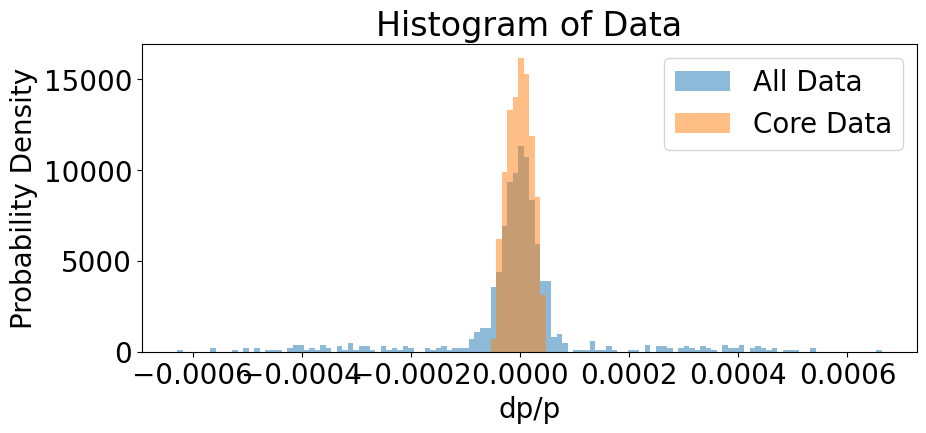

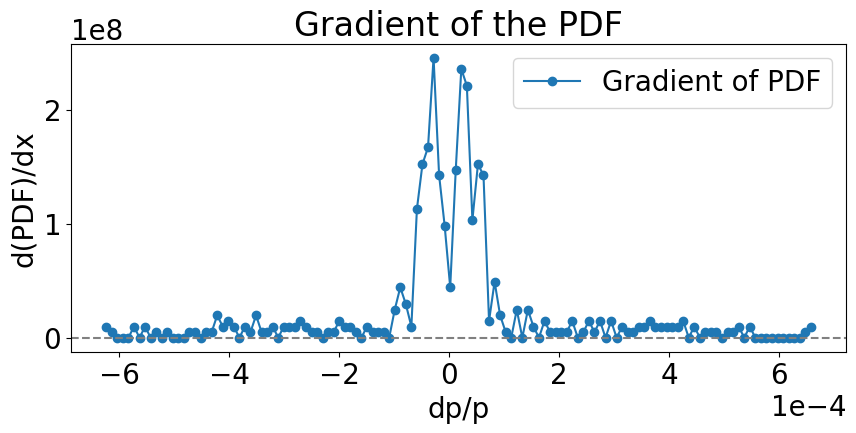

In [39]:
import numpy as np
import matplotlib.pyplot as plt



# Assume delta_perc is already defined; use its last element
delta_perc_final = delta_perc[-1]

n_bins=freedman_diaconis_bins(delta_perc_final)


# Define the core using the 15th and 85th percentiles.
p20, p80 = np.percentile(delta_perc_final, [15, 85])
core = delta_perc_final[(delta_perc_final >= p20) & (delta_perc_final <= p80)]

# Set up histogram bins based on the range of delta_perc_final.
bins = np.linspace(np.min(delta_perc_final), np.max(delta_perc_final), n_bins)

# Plot the histograms for visualization
plt.figure(figsize=(10, 4))
plt.hist(delta_perc_final, bins=bins, alpha=0.5, label='All Data', density=True)
plt.hist(core, bins=bins, alpha=0.5, label='Core Data', density=True)
plt.xlabel('dp/p')
plt.ylabel('Probability Density')
plt.legend()
plt.title('Histogram of Data')
plt.show()

# Compute the PDF of delta_perc_final using a histogram.
# Use density=True so that the histogram approximates a PDF.
pdf_counts, bin_edges = np.histogram(delta_perc_final, bins=bins, density=True)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# Calculate the numerical gradient of the PDF.
dx = bin_centers[1] - bin_centers[0]  # uniform spacing
pdf_gradient = np.gradient(pdf_counts, dx)

max_grad=np.max(np.abs(pdf_gradient))

# Plot the gradient of the PDF.
plt.figure(figsize=(10, 4))
plt.plot(bin_centers, np.abs(pdf_gradient), marker='o', label='Gradient of PDF')
plt.xlabel('dp/p')
plt.ylabel('d(PDF)/dx')
plt.title('Gradient of the PDF')
plt.axhline(0, color='gray', linestyle='--')
plt.legend()
# plt.yscale("log")
# plt.axhline(max_grad/100)
plt.ticklabel_format(style='sci', axis='x', scilimits=(0, 0))
plt.show()


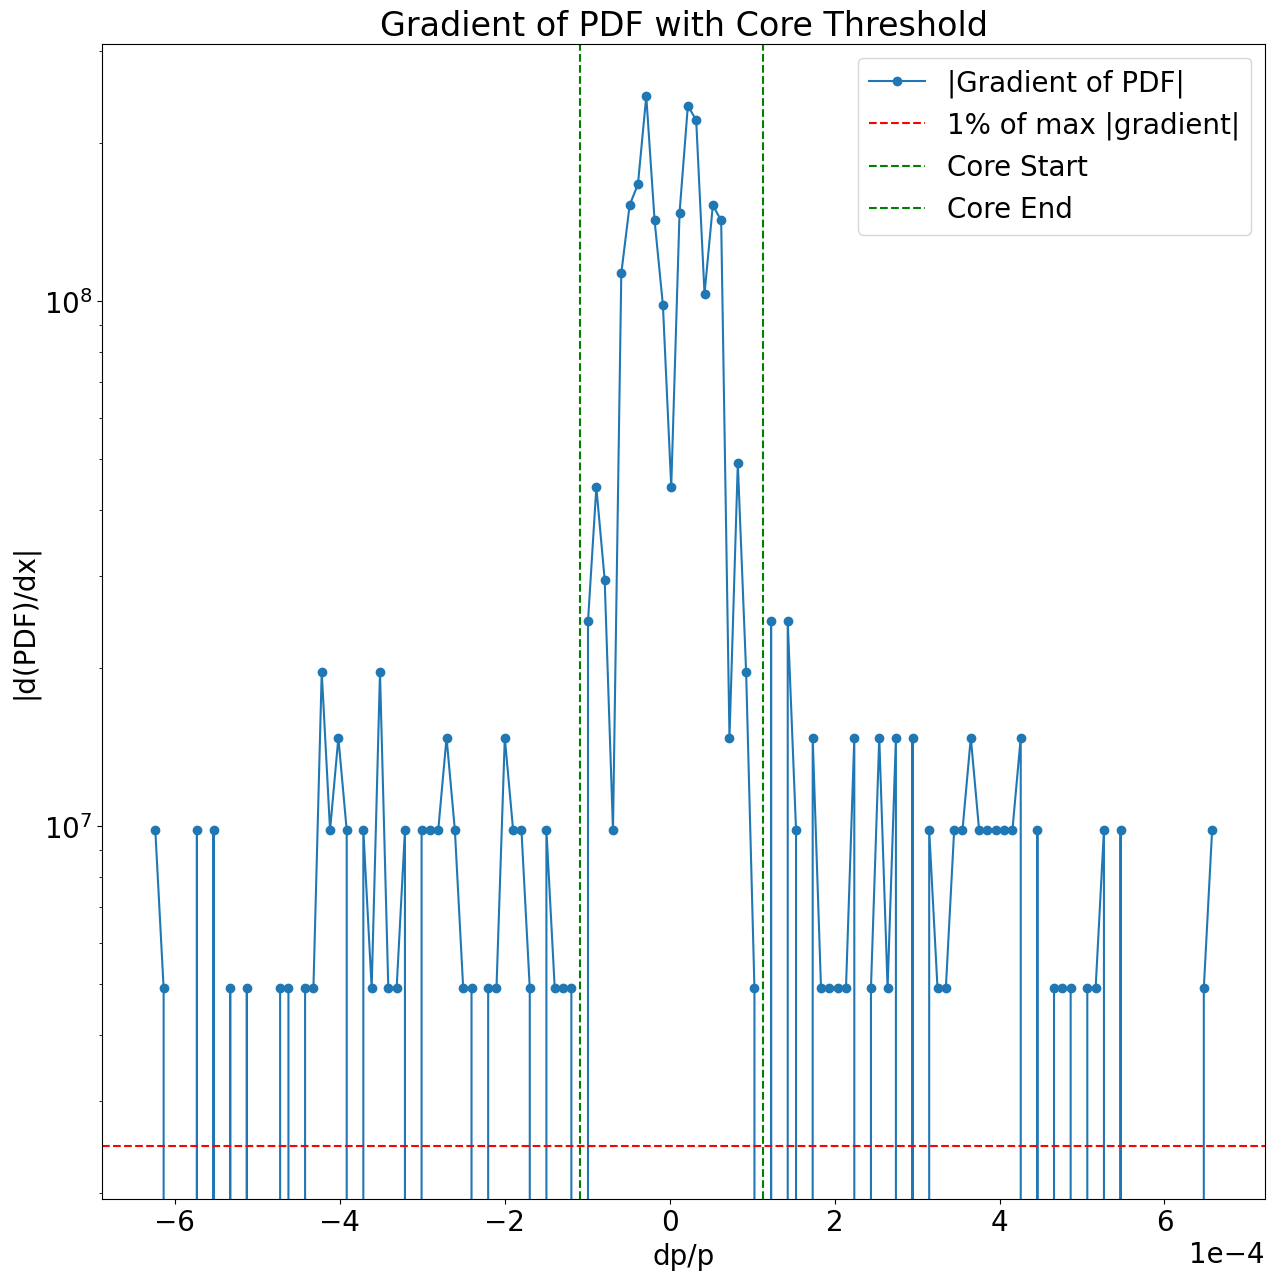

Core region: -1.09e-04 to 1.13e-04
Core points: 859, Tail points: 141


In [40]:
import numpy as np
import matplotlib.pyplot as plt

# Assume delta_perc, freedman_diaconis_bins are defined
delta_perc_final = delta_perc[-1]
n_bins = freedman_diaconis_bins(delta_perc_final)

# Histogram + PDF
bins = np.linspace(np.min(delta_perc_final), np.max(delta_perc_final), n_bins)
pdf_counts, bin_edges = np.histogram(delta_perc_final, bins=bins, density=True)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
dx = bin_centers[1] - bin_centers[0]
pdf_gradient = np.gradient(pdf_counts, dx)
abs_grad = np.abs(pdf_gradient)
max_grad = np.max(abs_grad)

# Threshold for core (1% of max gradient)
threshold = max_grad / 100

# Find core bounds based on where gradient falls below threshold
peak_index = np.argmax(pdf_counts)

# Scan left
left_index = peak_index
while left_index > 0 and abs_grad[left_index] > threshold:
    left_index -= 1

# Scan right
right_index = peak_index
while right_index < len(abs_grad) - 1 and abs_grad[right_index] > threshold:
    right_index += 1

# Core bounds in terms of x-values
core_left = bin_centers[left_index]
core_right = bin_centers[right_index]

# Separate core and tail data
core_data = delta_perc_final[(delta_perc_final >= core_left) & (delta_perc_final <= core_right)]
tail_data = delta_perc_final[(delta_perc_final < core_left) | (delta_perc_final > core_right)]

# ---- Plotting ----

# Gradient Plot (Log Scale)
plt.figure(figsize=(15,15))
plt.plot(bin_centers, abs_grad, marker='o', label='|Gradient of PDF|')
plt.axhline(threshold, color='red', linestyle='--', label='1% of max |gradient|')
plt.axvline(core_left, color='green', linestyle='--', label='Core Start')
plt.axvline(core_right, color='green', linestyle='--', label='Core End')
plt.xlabel('dp/p')
plt.ylabel('|d(PDF)/dx|')
plt.yscale('log')
plt.title('Gradient of PDF with Core Threshold')
plt.legend()
plt.ticklabel_format(style='sci', axis='x', scilimits=(0, 0))
plt.show()

# Print results
print(f"Core region: {core_left:.2e} to {core_right:.2e}")
print(f"Core points: {len(core_data)}, Tail points: {len(tail_data)}")


In [41]:
def freedman_diaconis_bins(data):
    """Determine optimal bin count using Freedman-Diaconis rule."""
    if len(data) < 2:
        return 1  # Avoid division errors
    q25, q75 = np.percentile(data, [25, 75])
    iqr = q75 - q25
    bin_width = 2 * iqr * len(data) ** (-1 / 3)
    bins = max(5, int((np.max(data) - np.min(data)) / bin_width))  # At least 5 bins
    return bins

def extract_core_from_gradient(data: np.ndarray, threshold_frac: float = 0.01) -> np.ndarray:
    
    n_bins = freedman_diaconis_bins(data)

    # Histogram and PDF
    bins = np.linspace(np.min(data), np.max(data), n_bins)
    pdf_counts, bin_edges = np.histogram(data, bins=bins, density=True)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    dx = bin_centers[1] - bin_centers[0]

    # Compute gradient of PDF
    pdf_gradient = np.gradient(pdf_counts, dx)
    abs_grad = np.abs(pdf_gradient)
    max_grad = np.max(abs_grad)
    threshold = max_grad * threshold_frac

    # Find peak of PDF
    peak_index = np.argmax(pdf_counts)

    # Find left bound
    left_index = peak_index
    while left_index > 0 and abs_grad[left_index] > threshold:
        left_index -= 1

    # Find right bound
    right_index = peak_index
    while right_index < len(abs_grad) - 1 and abs_grad[right_index] > threshold:
        right_index += 1

    core_left = bin_centers[left_index]
    core_right = bin_centers[right_index]

    # Extract core data
    core_data = data[(data >= core_left) & (data <= core_right)]

    return core_data

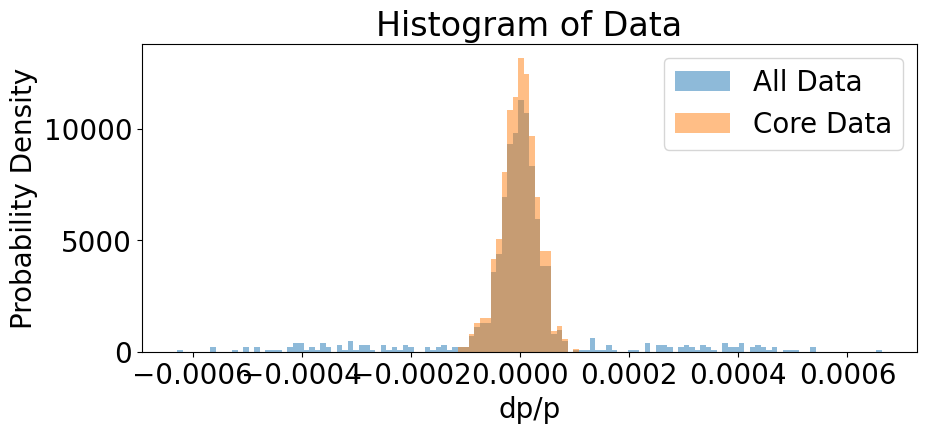

In [42]:
# Plot the histograms for visualization
plt.figure(figsize=(10, 4))
plt.hist(delta_perc_final, bins=bins, alpha=0.5, label='All Data', density=True)
plt.hist(extract_core_from_gradient(delta_perc_final,threshold_frac=0.00001), bins=bins, alpha=0.5, label='Core Data', density=True)
plt.xlabel('dp/p')
plt.ylabel('Probability Density')
plt.legend()
plt.title('Histogram of Data')
plt.show()

In [43]:
x = 3 * sigma
decay = np.exp(-x**2 / (2 * sigma**2))
print(decay*100)

1.1108996538242317


In [44]:
max(np.abs(pdf_gradient))

np.float64(245558656.69756356)

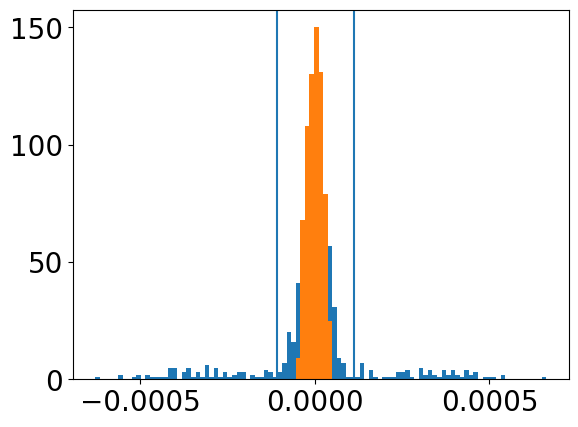

In [45]:
delta_perc_final=delta_perc[-1]

p20, p80 = np.percentile(delta_perc_final, [15, 85])
core = delta_perc_final[(delta_perc_final >= p20) & (delta_perc_final <= p80)]



bins = np.linspace(min(delta_perc_final), max(delta_perc_final), 100)
plt.figure()

plt.hist(delta_perc_final,bins=bins)
plt.hist(core,bins=bins)
plt.axvline(core_left)
plt.axvline(core_right)

plt.show()

In [46]:
import numpy as np

sigma = 1
x = 3 * sigma

# Gaussian PDF at x
pdf = (1 / (np.sqrt(2 * np.pi) * sigma)) * np.exp(-x**2 / (2 * sigma**2))

# Derivative of the Gaussian PDF at x
pdf_derivative = (-x / sigma**2) * pdf

# Max of PDF is at x = 0
pdf_peak = 1 / (np.sqrt(2 * np.pi) * sigma)

# Express derivative magnitude as % of peak PDF
relative_grad = np.abs(pdf_derivative) / pdf_peak * 100

print(f"Gradient magnitude at x = 3σ: {relative_grad:.5f}% of PDF peak")


Gradient magnitude at x = 3σ: 3.33270% of PDF peak
